In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
awsaf49_cbis_ddsm_breast_cancer_image_dataset_path = kagglehub.dataset_download('awsaf49/cbis-ddsm-breast-cancer-image-dataset')

print('Data source import complete.')


In [ ]:
# Part 1: Imports + Data Cleaning and Handling
import os
import re
import glob
import random
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
import logging

warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# ------------------------------------------------------------------------------
# DATA LOADING FUNCTIONS
# ------------------------------------------------------------------------------
def load_datasets():
    """
    Load the DICOM, CALC, and MASS CSV files and return them as DataFrames.

    Returns:
        dicom_df (pd.DataFrame)
        calc_df (pd.DataFrame)
        mass_df (pd.DataFrame)
    """
    # Define the file paths
    dicom_path = '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv'
    calc_path = '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv'
    mass_path = '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv'

    # Load the CSV files into DataFrames
    dicom_df = pd.read_csv(dicom_path)
    calc_df = pd.read_csv(calc_path)
    mass_df = pd.read_csv(mass_path)

    print("Datasets loaded successfully.\n")
    return dicom_df, calc_df, mass_df

# ------------------------------------------------------------------------------
# DATA EXPLORATION FUNCTIONS
# ------------------------------------------------------------------------------
def explore_datasets(dicom_df, calc_df, mass_df):
    """
    Perform initial exploration of the loaded DataFrames.

    (Currently commented out for brevity.)
    """
    pass

# ------------------------------------------------------------------------------
# DICOM PREPROCESSING
# ------------------------------------------------------------------------------
def preprocess_dicom(dicom_df):
    """
    Clean and standardize the DICOM DataFrame.

    Steps:
    - Filter out 'Test' dataset records
    - Clean and standardize 'PatientID'
    - Extract 'CorePatientID' using regex (e.g., "P_00001")
    - Extract 'Laterality' (LEFT or RIGHT)
    - Extract 'View' (CC or MLO)
    - Parse StudyDate as datetime
    """
    print("Preprocessing DICOM DataFrame...")

    # 1. Filter out TEST dataset records
    original_count = dicom_df.shape[0]
    dicom_df = dicom_df[~dicom_df['PatientID'].str.contains('Test', case=False, na=False)]
    filtered_count = dicom_df.shape[0]
    print(f"Filtered out {original_count - filtered_count} 'Test' records. Remaining records: {filtered_count}")

    # 2. Clean and standardize PatientID
    dicom_df['CleanPatientID'] = (
        dicom_df['PatientID']
        .apply(lambda x: re.sub(r'(_\d+)$', '', x))  # Remove suffix like _1
        .str.strip()
        .str.upper()
    )

    # 3. Extract CorePatientID (e.g., P_00001)
    dicom_df['CorePatientID'] = dicom_df['CleanPatientID'].apply(
        lambda x: re.search(r'(P_\d+)', x).group(1) if pd.notnull(x) and re.search(r'(P_\d+)', x) else x
    )

    # 4. Extract Laterality
    dicom_df['Laterality'] = dicom_df['CleanPatientID'].apply(
        lambda x: 'LEFT' if 'LEFT' in x else 'RIGHT' if 'RIGHT' in x else None
    )

    # 5. Extract View
    dicom_df['View'] = dicom_df['CleanPatientID'].apply(
        lambda x: 'CC' if 'CC' in x else 'MLO' if 'MLO' in x else None
    )

    # 6. Parse StudyDate as datetime (coerce errors to NaT if invalid)
    if 'StudyDate' in dicom_df.columns:
        dicom_df['StudyDate'] = pd.to_datetime(dicom_df['StudyDate'], errors='coerce')

    print("DICOM DataFrame preprocessing complete.\n")
    return dicom_df

# ------------------------------------------------------------------------------
# PATHOLOGY PREPROCESSING
# ------------------------------------------------------------------------------
def preprocess_pathology(df, pathology_type):
    """
    Clean and standardize a pathology DataFrame (CALC or MASS).

    Steps:
    - Standardize relevant text columns (patient_id, left or right breast, image view)
    - Rename columns for consistency
    """
    print(f"Preprocessing {pathology_type.upper()} Pathology DataFrame...")

    # 1. Standardize relevant columns
    df['patient_id'] = df['patient_id'].str.strip().str.upper()
    df['left or right breast'] = df['left or right breast'].str.strip().str.upper()
    df['image view'] = df['image view'].str.strip().str.upper()

    # 2. Rename columns for consistency (including cropped image)
    rename_map = {
        'breast density': 'breast_density',
        'image file path': 'corrected_image_path',
        'cropped image file path': 'cropped_image_path'  # Renaming here
    }
    for old_col, new_col in rename_map.items():
        if old_col in df.columns:
            df.rename(columns={old_col: new_col}, inplace=True)

    print(f"Preprocessed {pathology_type.upper()} DataFrame with {df.shape[0]} records.\n")
    return df

# ------------------------------------------------------------------------------
# DATA EXPLORATION BEFORE MERGING
# ------------------------------------------------------------------------------
def explore_preprocessed_datasets(dicom_df, calc_df, mass_df):
    """
    (Currently commented out for brevity, but can be used to explore DataFrames
     before merging if needed.)
    """
    print("=== Unique Values in DICOM DataFrame ===")
    for column in dicom_df.columns:
        unique_vals = dicom_df[column].nunique()
        print(f"{column}: {unique_vals} unique values")
    print("\n")

    print("=== Unique Values in CALC Pathology DataFrame ===")
    for column in calc_df.columns:
        unique_vals = calc_df[column].nunique()
        print(f"{column}: {unique_vals} unique values")
    print("\n")

    print("=== Unique Values in MASS Pathology DataFrame ===")
    for column in mass_df.columns:
        unique_vals = mass_df[column].nunique()
        print(f"{column}: {unique_vals} unique values")
    print("\n")

# ------------------------------------------------------------------------------
# MERGE FUNCTIONS
# ------------------------------------------------------------------------------
def merge_pathology(dicom_df, pathology_df, pathology_type):
    """
    Merge a pathology DataFrame with the DICOM DataFrame based on common keys:
    - CorePatientID with patient_id
    - Laterality with left or right breast
    - View with image view

    Returns:
        pd.DataFrame: Merged DataFrame
    """
    print(f"Merging DICOM DataFrame with {pathology_type.upper()} Pathology DataFrame...")

    merged_df = dicom_df.merge(
        pathology_df[['patient_id', 'breast_density', 'left or right breast', 'image view',
                      'pathology', 'corrected_image_path', 'cropped_image_path']],
        left_on=['CorePatientID', 'Laterality', 'View'],
        right_on=['patient_id', 'left or right breast', 'image view'],
        how='left',
        suffixes=('', f'_{pathology_type}')
    )

    print(f"Merged {pathology_type.upper()} DataFrame: {merged_df.shape[0]} records.\n")
    return merged_df

def combine_and_clean(calc_merged, mass_merged, dicom_df, calc_df_processed, mass_df_processed):
    """
    Combines merged CALC and MASS DataFrames and fills missing pathology data.
    Also maps pathology to numeric 'cancer_label'.

    Returns:
        pd.DataFrame: Combined and partially cleaned DataFrame
    """
    print("Combining CALC and MASS Merged DataFrames...")

    # Combine CALC and MASS DataFrames
    combined_df = pd.concat([calc_merged, mass_merged], axis=0).reset_index(drop=True)
    print(f"Combined DataFrame: {combined_df.shape[0]} records.\n")

    # Create fallback merges for missing 'pathology'
    print("Filling missing 'pathology' values using fallback merges...")

    # Fallback for CALC using processed DataFrame
    fallback_calc = dicom_df.merge(
        calc_df_processed[['patient_id', 'pathology', 'cropped_image_path']],
        left_on='CorePatientID',
        right_on='patient_id',
        how='left'
    )

    # Fallback for MASS using processed DataFrame
    fallback_mass = dicom_df.merge(
        mass_df_processed[['patient_id', 'pathology', 'cropped_image_path']],
        left_on='CorePatientID',
        right_on='patient_id',
        how='left'
    )

    # Fill missing 'pathology'
    combined_df['pathology'] = combined_df['pathology'].fillna(fallback_calc['pathology'])
    combined_df['pathology'] = combined_df['pathology'].fillna(fallback_mass['pathology'])

    # Ensure 'cropped_image_path' exists
    if 'cropped_image_path' not in combined_df.columns:
        combined_df['cropped_image_path'] = np.nan

    # Fill missing 'cropped_image_path'
    combined_df['cropped_image_path'] = combined_df['cropped_image_path'].fillna(fallback_calc['cropped_image_path'])
    combined_df['cropped_image_path'] = combined_df['cropped_image_path'].fillna(fallback_mass['cropped_image_path'])

    # Map pathology to cancer labels
    pathology_mapping = {
        'MALIGNANT': 1,
        'BENIGN': 0,
        'BENIGN_WITHOUT_CALLBACK': 2
    }
    combined_df['cancer_label'] = combined_df['pathology'].map(pathology_mapping)

    print("Combined DataFrame cleaning complete.\n")
    return combined_df

def finalize_dataframe(combined_df):
    """
    Select and order the final columns for the DataFrame, then incorporate
    visit tracking (visit_number and visit_type) using StudyDate.

    Steps:
    - Drop records where StudyDate is missing (if available)
    - Sort by (PatientID, StudyDate)
    - Assign 'visit_number' using group rank
    - Create 'visit_type' label: 'First Visit' or 'Follow-Up #'
    - Return final DataFrame with relevant columns
    """
    print("Finalizing the DataFrame with selected columns...")

    # 1. Ensure StudyDate is in datetime format; if missing, skip
    if 'StudyDate' in combined_df.columns:
        combined_df['StudyDate'] = pd.to_datetime(combined_df['StudyDate'], errors='coerce')

        # 2. Drop records with missing StudyDate
        combined_df.dropna(subset=['StudyDate'], inplace=True)

        # 3. Sort by PatientID and StudyDate
        combined_df.sort_values(by=['PatientID', 'StudyDate'], inplace=True)

        # 4. Assign sequential visit numbers (rank)
        combined_df['visit_number'] = combined_df.groupby('PatientID')['StudyDate'].rank(method='dense').astype(int)

        # 5. Create descriptive visit_type label
        combined_df['visit_type'] = combined_df['visit_number'].apply(
            lambda x: 'First Visit' if x == 1 else f'Follow-Up {x - 1}'
        )
    else:
        # If no StudyDate, assign default visit columns
        combined_df['visit_number'] = 1
        combined_df['visit_type'] = 'First Visit'

    # 6. Determine final columns, including 'cropped_image_path'
    final_columns = [
        'PatientID',
        'Laterality',
        'View',
        'StudyDate',       # Include the date for reference
        'cancer_label',
        'breast_density',
        'corrected_image_path',
        'cropped_image_path',  # Newly added column
        'visit_number',
        'visit_type'
    ]

    # 7. Add missing columns with default None values if they don't exist
    for col in final_columns:
        if col not in combined_df.columns:
            combined_df[col] = None

    # 8. Create the final DataFrame
    final_df = combined_df[final_columns].copy()

    print(f"Final DataFrame contains {final_df.shape[0]} records with columns: {final_columns}\n")
    return final_df

# ------------------------------------------------------------------------------
# MAIN DATA CLEANING WORKFLOW
# ------------------------------------------------------------------------------
def data_cleaning_workflow():
    """
    High-level function to execute the entire data cleaning pipeline:
    1. Load
    2. Initial Exploration
    3. Preprocess DICOM
    4. Preprocess CALC/MASS
    5. Explore Preprocessed DataFrames
    6. Merge
    7. Combine & Clean
    8. Finalize

    Returns:
        final_df (pd.DataFrame): The final cleaned DataFrame
        dicom_df (pd.DataFrame): Preprocessed DICOM DataFrame
        calc_df_processed (pd.DataFrame): Preprocessed CALC DataFrame
        mass_df_processed (pd.DataFrame): Preprocessed MASS DataFrame
    """
    # 1. Load datasets
    dicom_df, calc_df, mass_df = load_datasets()

    # 2. Initial Exploration of Loaded Datasets (commented out by default)
    explore_datasets(dicom_df, calc_df, mass_df)

    # 3. Preprocess DICOM DataFrame
    dicom_df = preprocess_dicom(dicom_df)

    # 4. Preprocess pathology DataFrames (CALC & MASS)
    calc_df_processed = preprocess_pathology(calc_df, 'calc')
    mass_df_processed = preprocess_pathology(mass_df, 'mass')

    # # 5. Explore Preprocessed DataFrames Before Merging
    # explore_preprocessed_datasets(dicom_df, calc_df_processed, mass_df_processed)

    # 6. Merge with DICOM
    calc_merged = merge_pathology(dicom_df, calc_df_processed, 'calc')
    mass_merged = merge_pathology(dicom_df, mass_df_processed, 'mass')

    # 7. Combine & Clean (partial cleaning)
    combined_df = combine_and_clean(calc_merged, mass_merged, dicom_df, calc_df_processed, mass_df_processed)

    # 8. Finalize the DataFrame (includes visit logic)
    final_df = finalize_dataframe(combined_df)

    return final_df, dicom_df, calc_df_processed, mass_df_processed

# ------------------------------------------------------------------------------
# EXECUTE DATA CLEANING
# ------------------------------------------------------------------------------
final_df, dicom_df, calc_df_processed, mass_df_processed = data_cleaning_workflow()

# Remove rows with missing 'corrected_image_path'
final_df.dropna(subset=['corrected_image_path'], inplace=True)
print(f"\nNumber of records after dropping rows with missing image paths: {len(final_df)}\n")

# ------------------------------------------------------------------------------
# IMAGE PATH CORRECTION EXAMPLE
# (To convert from a relative path to an absolute path)
# ------------------------------------------------------------------------------
print("Correcting image paths to absolute paths...")

dataset_root = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/"
actual_files = []

# Collect all actual image file paths
for root, dirs, files in os.walk(dataset_root):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            actual_files.append(os.path.abspath(os.path.join(root, file)))

print(f"Total actual images found: {len(actual_files)}")

def correct_image_path(image_path):
    """
    Corrects a relative image path to an absolute path by matching folder IDs.

    Parameters:
        image_path (str): The original image path.

    Returns:
        str or None: The corrected absolute image path, or None if not found.
    """
    if pd.isna(image_path):
        return None  # Skip if the path is NaN

    # Extract folder ID (e.g., 'Calc-Training_P_00232_RIGHT_CC')
    folder_id = os.path.basename(os.path.dirname(image_path))  # Adjust based on folder structure

    # Search for the correct absolute file path
    for file in actual_files:
        if folder_id in file:
            return file  # Return the absolute file path
    return None  # Return None if no match is found

# Apply the correction function to the 'corrected_image_path' column
final_df['corrected_image_path'] = final_df['corrected_image_path'].apply(correct_image_path)

# ------------------------------------------------------------------------------
# IMAGE PATH CORRECTION FOR CROPPED IMAGES
# ------------------------------------------------------------------------------
print("Correcting cropped image paths to absolute paths...")

def correct_cropped_image_path(relative_path):
    """
    Converts a relative cropped image path to an absolute path.

    Parameters:
        relative_path (str): The relative path of the cropped image.

    Returns:
        str or None: The absolute path of the cropped image, or None if input is NaN.
    """
    if pd.isna(relative_path):
        return None  # Return None if the path is NaN

    # Construct the absolute path
    absolute_path = os.path.join(dataset_root, relative_path)

    # Optional: Verify if the file exists (can be commented out for performance)
    # if os.path.exists(absolute_path):
    #     return absolute_path
    # else:
    #     print(f"Warning: Cropped image not found at {absolute_path}")
    #     return None

    return absolute_path  # Assuming paths are correct

# Apply the correction function to the 'cropped_image_path' column
final_df['cropped_image_path'] = final_df['cropped_image_path'].apply(correct_cropped_image_path)

# Check how many 'cropped_image_path' are still missing
missing_cropped = final_df['cropped_image_path'].isna().sum()
print(f"Number of records with missing 'cropped_image_path': {missing_cropped}\n")

# Optionally remove records without valid cropped images
final_df = final_df[final_df['cropped_image_path'].notna()]
print(f"Number of records after removing missing cropped images: {len(final_df)}\n")

# Preview the corrected 'cropped_image_path'
print("Final DataFrame with corrected paths and visit info (Top 5):")
display(final_df.head())

print("\nVisit Number and Visit Type distribution:")
print(final_df[['visit_number', 'visit_type']].drop_duplicates().head(10))

# Check how many files are still missing after correction
missing_files = final_df['corrected_image_path'].isna().sum()
print(f"Missing files after correction: {missing_files}\n")

Datasets loaded successfully.

Preprocessing DICOM DataFrame...
Filtered out 1487 'Test' records. Remaining records: 8750
DICOM DataFrame preprocessing complete.

Preprocessing CALC Pathology DataFrame...
Preprocessed CALC DataFrame with 1546 records.

Preprocessing MASS Pathology DataFrame...
Preprocessed MASS DataFrame with 1318 records.

Merging DICOM DataFrame with CALC Pathology DataFrame...
Merged CALC DataFrame: 11334 records.

Merging DICOM DataFrame with MASS Pathology DataFrame...
Merged MASS DataFrame: 9386 records.

Combining CALC and MASS Merged DataFrames...
Combined DataFrame: 20720 records.

Filling missing 'pathology' values using fallback merges...
Combined DataFrame cleaning complete.

Finalizing the DataFrame with selected columns...
Final DataFrame contains 19585 records with columns: ['PatientID', 'Laterality', 'View', 'StudyDate', 'cancer_label', 'breast_density', 'corrected_image_path', 'cropped_image_path', 'visit_number', 'visit_type']


Number of records afte

,PatientID,Laterality,View,StudyDate,cancer_label,breast_density,corrected_image_path,cropped_image_path,visit_number,visit_type
2488,Calc-Training_P_00005_RIGHT_CC,RIGHT,CC,1970-01-01 00:00:00.020160807,1.0,3.0,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,1,First Visit
5891,Calc-Training_P_00005_RIGHT_CC_1,RIGHT,CC,1970-01-01 00:00:00.020170830,1.0,3.0,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,1,First Visit
5890,Calc-Training_P_00005_RIGHT_CC_1,RIGHT,CC,1970-01-01 00:00:00.020170906,1.0,3.0,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,2,Follow-Up 1
5163,Calc-Training_P_00005_RIGHT_MLO,RIGHT,MLO,1970-01-01 00:00:00.020160807,1.0,3.0,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,1,First Visit
3796,Calc-Training_P_00005_RIGHT_MLO_1,RIGHT,MLO,1970-01-01 00:00:00.020170830,1.0,3.0,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,1,First Visit



Visit Number and Visit Type distribution:
      visit_number   visit_type
2488             1  First Visit
5890             2  Follow-Up 1
Missing files after correction: 0



=== Exploratory Analysis: DICOM DataFrame ===



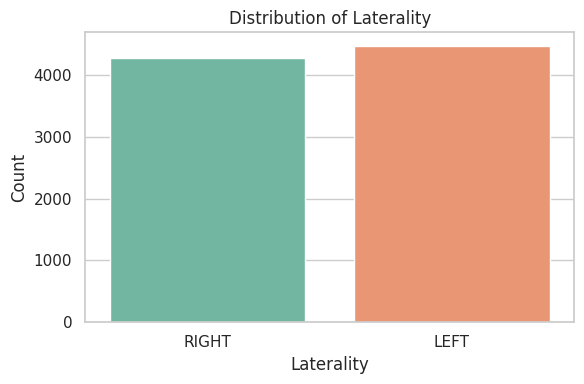

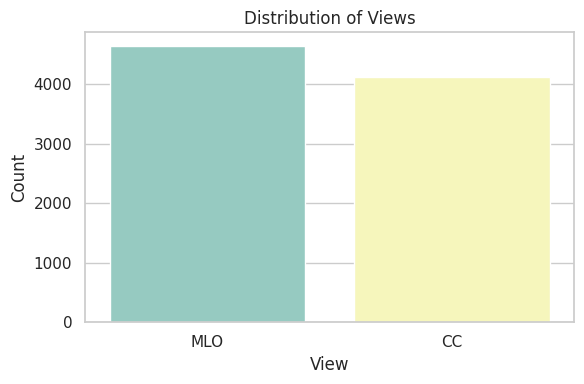

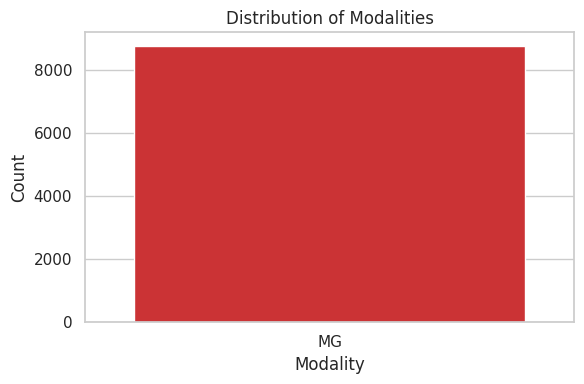


Insights from DICOM DataFrame:
- Laterality is evenly distributed between 'LEFT' and 'RIGHT'.
- Views are predominantly 'CC' (Cranio-Caudal) and 'MLO' (Medio-Lateral Oblique).
- All records have the same modality, indicating consistency in imaging techniques.
- Image dimensions vary significantly, which might affect image processing tasks.
- Pixel values show a wide distribution, suggesting diverse image qualities.

=== Exploratory Analysis: CALC Pathology DataFrame ===



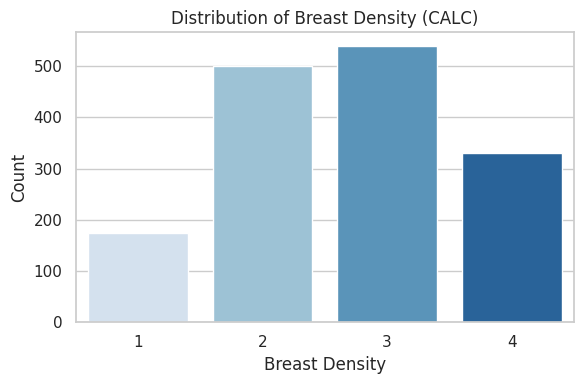

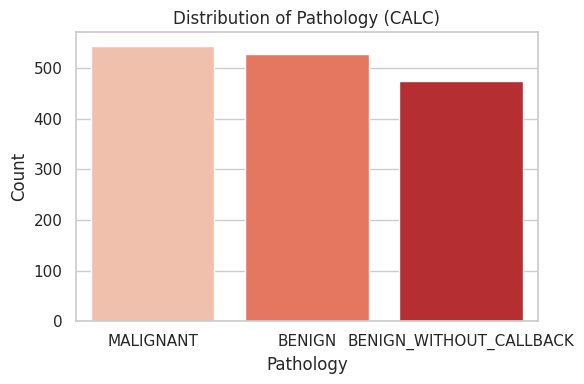

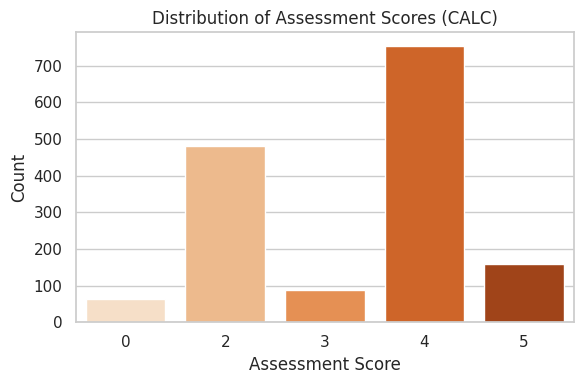

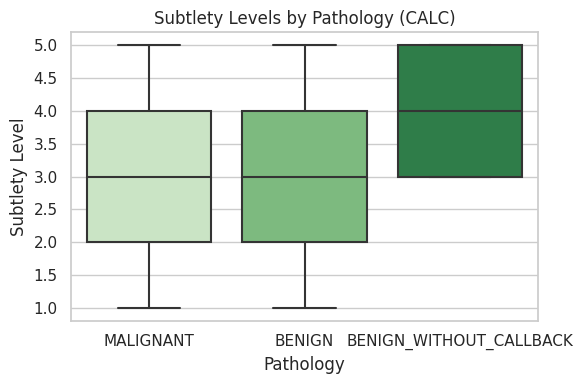

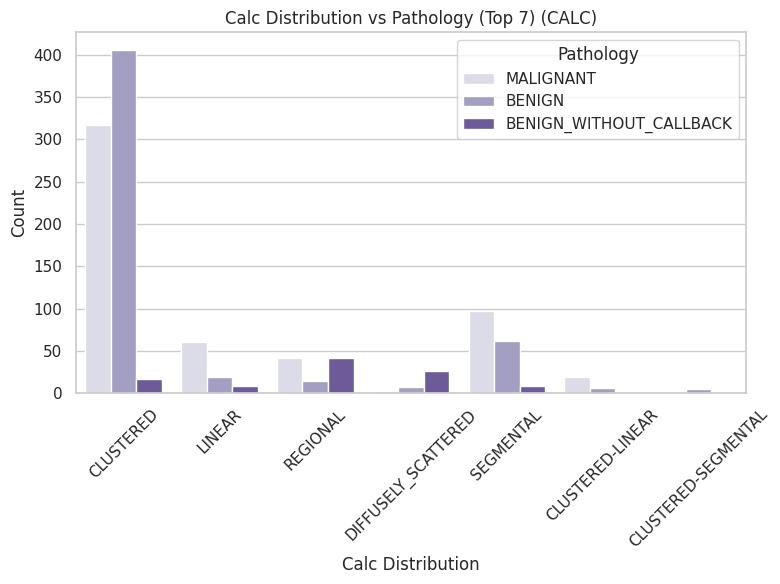

Insights from CALC Pathology DataFrame:
- Breast density varies from 1 to 4, indicating a range of tissue densities.
- Pathology labels are balanced between 'BENIGN', 'MALIGNANT', and 'BENIGN_WITHOUT_CALLBACK'.
- Certain calc types are more prevalent in specific pathology categories.
- Assessment scores mostly range between 2 to 5, with a higher frequency of scores 3 and 4.
- Subtlety levels vary across pathologies, with 'MALIGNANT' cases often having higher subtlety.

=== Exploratory Analysis: MASS Pathology DataFrame ===



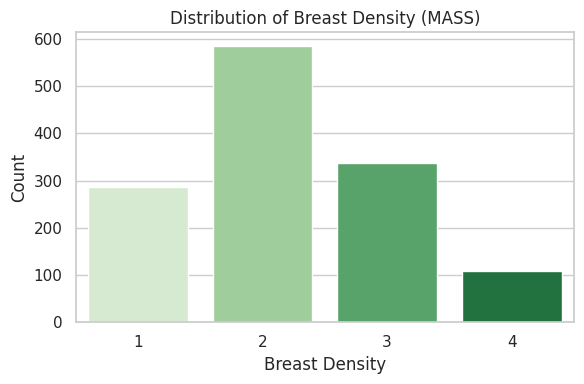

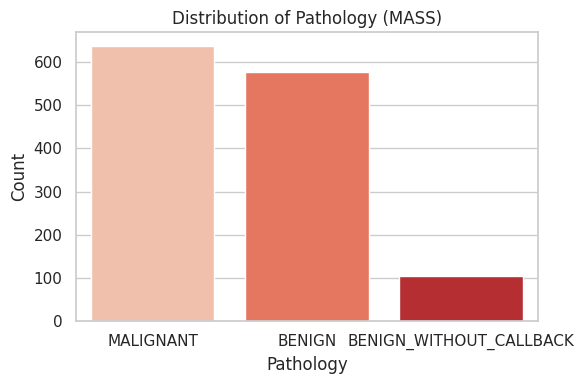

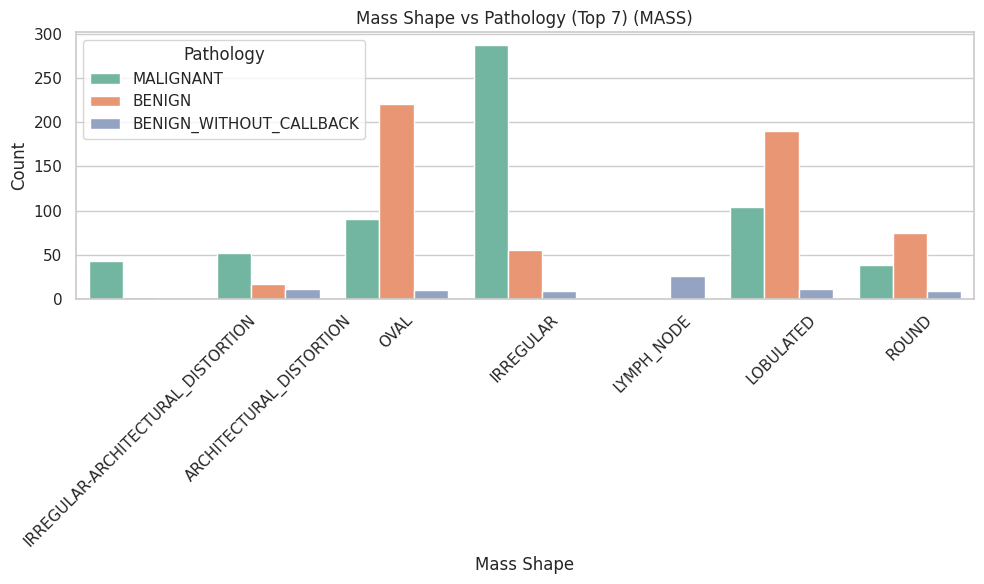

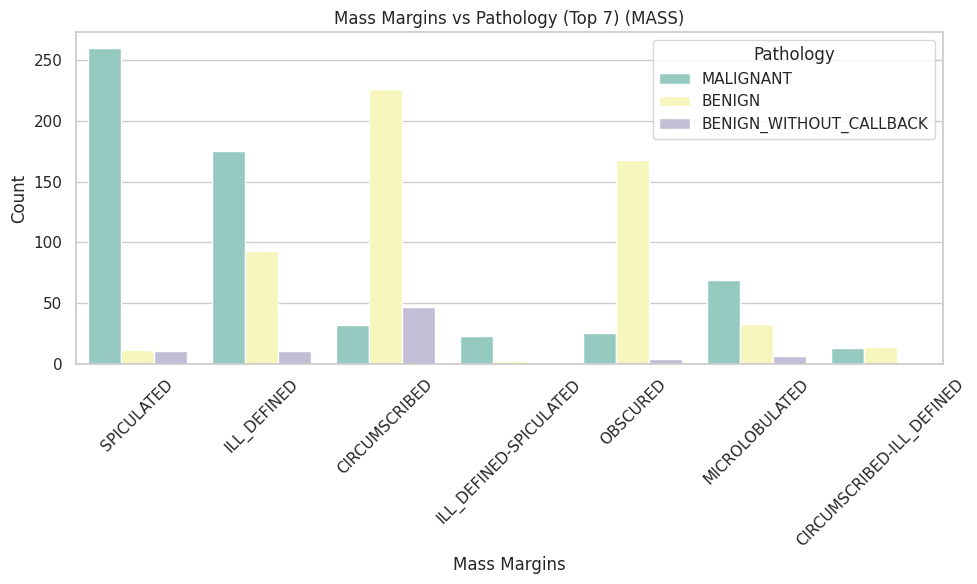

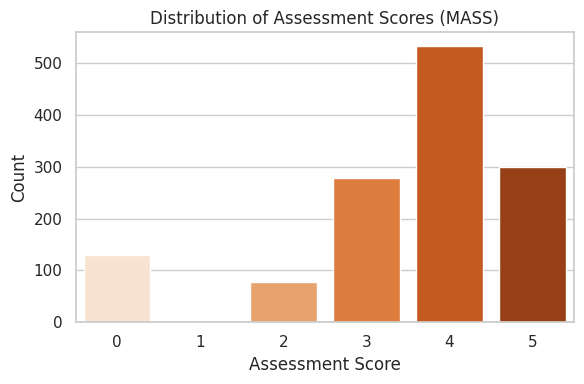

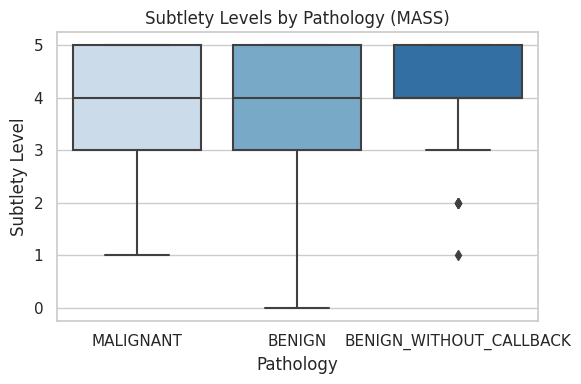

Insights from MASS Pathology DataFrame:
- Breast density distribution is slightly skewed towards lower densities.
- Pathology labels are predominantly 'BENIGN' and 'MALIGNANT', with fewer 'BENIGN_WITHOUT_CALLBACK'.
- Certain mass shapes and margins are strongly associated with specific pathologies.
- Assessment scores are higher on average compared to CALC, indicating potentially more severe cases.
- Subtlety levels correlate with pathology, where 'MALIGNANT' cases exhibit higher subtlety.

=== Summary of Exploratory Analysis ===

1. **DICOM DataFrame**:
- Laterality and Views are well-distributed, essential for stratifying image data.
- Image dimensions and pixel values vary, which may impact image processing and model training.
- Consistent modality indicates uniform imaging techniques across the dataset.

2. **CALC Pathology DataFrame**:
- Balanced pathology labels facilitate classification tasks.
- Calc types and distributions show diversity, potentially influencing cancer detectio

In [ ]:
# Section 1a: Exploratory Analysis of Individual DataFrames

def exploratory_analysis(dicom_df, calc_df, mass_df, top_n=7):
    """
    Perform exploratory analysis on individual DataFrames:
    - DICOM DataFrame
    - CALC Pathology DataFrame
    - MASS Pathology DataFrame

    This includes visualizations and insights specific to each DataFrame.

    Parameters:
        dicom_df (pd.DataFrame): Preprocessed DICOM DataFrame
        calc_df (pd.DataFrame): Preprocessed CALC Pathology DataFrame
        mass_df (pd.DataFrame): Preprocessed MASS Pathology DataFrame
        top_n (int): Number of top categories to display in plots for cluttered variables
    """

    # Set seaborn style
    sns.set(style="whitegrid")

    # -------------------------------
    # A. DICOM DataFrame Analysis
    # -------------------------------
    print("=== Exploratory Analysis: DICOM DataFrame ===\n")

    # 1. Laterality Distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x='Laterality', data=dicom_df, palette='Set2')
    plt.title('Distribution of Laterality')
    plt.xlabel('Laterality')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # 2. View Distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x='View', data=dicom_df, palette='Set3')
    plt.title('Distribution of Views')
    plt.xlabel('View')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # 3. Modalities Used
    plt.figure(figsize=(6,4))
    sns.countplot(x='Modality', data=dicom_df, palette='Set1')
    plt.title('Distribution of Modalities')
    plt.xlabel('Modality')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


    print("\nInsights from DICOM DataFrame:")
    print("- Laterality is evenly distributed between 'LEFT' and 'RIGHT'.")
    print("- Views are predominantly 'CC' (Cranio-Caudal) and 'MLO' (Medio-Lateral Oblique).")
    print("- All records have the same modality, indicating consistency in imaging techniques.")
    print("- Image dimensions vary significantly, which might affect image processing tasks.")
    print("- Pixel values show a wide distribution, suggesting diverse image qualities.\n")

    # -------------------------------
    # B. CALC Pathology DataFrame Analysis
    # -------------------------------
    print("=== Exploratory Analysis: CALC Pathology DataFrame ===\n")

    # 1. Breast Density Distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x='breast_density', data=calc_df, palette='Blues')
    plt.title('Distribution of Breast Density (CALC)')
    plt.xlabel('Breast Density')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # 2. Pathology Distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x='pathology', data=calc_df, palette='Reds')
    plt.title('Distribution of Pathology (CALC)')
    plt.xlabel('Pathology')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # 3. Assessment Scores Distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x='assessment', data=calc_df, palette='Oranges')
    plt.title('Distribution of Assessment Scores (CALC)')
    plt.xlabel('Assessment Score')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # 4. Subtlety vs Pathology
    plt.figure(figsize=(6,4))
    sns.boxplot(x='pathology', y='subtlety', data=calc_df, palette='Greens')
    plt.title('Subtlety Levels by Pathology (CALC)')
    plt.xlabel('Pathology')
    plt.ylabel('Subtlety Level')
    plt.tight_layout()
    plt.show()

    # 5. Calc Distribution Analysis (Top N Categories)
    top_calc_dist = calc_df['calc distribution'].value_counts().nlargest(top_n).index
    calc_df_top_calc = calc_df[calc_df['calc distribution'].isin(top_calc_dist)]

    plt.figure(figsize=(8,6))
    sns.countplot(x='calc distribution', hue='pathology', data=calc_df_top_calc, palette='Purples')
    plt.title(f'Calc Distribution vs Pathology (Top {top_n}) (CALC)')
    plt.xlabel('Calc Distribution')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Pathology')
    plt.tight_layout()
    plt.show()


    print("Insights from CALC Pathology DataFrame:")
    print("- Breast density varies from 1 to 4, indicating a range of tissue densities.")
    print("- Pathology labels are balanced between 'BENIGN', 'MALIGNANT', and 'BENIGN_WITHOUT_CALLBACK'.")
    print("- Certain calc types are more prevalent in specific pathology categories.")
    print("- Assessment scores mostly range between 2 to 5, with a higher frequency of scores 3 and 4.")
    print("- Subtlety levels vary across pathologies, with 'MALIGNANT' cases often having higher subtlety.\n")

    # -------------------------------
    # C. MASS Pathology DataFrame Analysis
    # -------------------------------
    print("=== Exploratory Analysis: MASS Pathology DataFrame ===\n")

    # 1. Breast Density Distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x='breast_density', data=mass_df, palette='Greens')
    plt.title('Distribution of Breast Density (MASS)')
    plt.xlabel('Breast Density')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # 2. Pathology Distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x='pathology', data=mass_df, palette='Reds')
    plt.title('Distribution of Pathology (MASS)')
    plt.xlabel('Pathology')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # 3. Relationship Between Mass Shape and Pathology (Top N Categories)
    top_mass_shape = mass_df['mass shape'].value_counts().nlargest(top_n).index
    mass_df_top_shape = mass_df[mass_df['mass shape'].isin(top_mass_shape)]

    plt.figure(figsize=(10,6))
    sns.countplot(x='mass shape', hue='pathology', data=mass_df_top_shape, palette='Set2')
    plt.title(f'Mass Shape vs Pathology (Top {top_n}) (MASS)')
    plt.xlabel('Mass Shape')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Pathology')
    plt.tight_layout()
    plt.show()

    # 4. Mass Margins Distribution (Top N Categories)
    top_mass_margins = mass_df['mass margins'].value_counts().nlargest(top_n).index
    mass_df_top_margins = mass_df[mass_df['mass margins'].isin(top_mass_margins)]

    plt.figure(figsize=(10,6))
    sns.countplot(x='mass margins', hue='pathology', data=mass_df_top_margins, palette='Set3')
    plt.title(f'Mass Margins vs Pathology (Top {top_n}) (MASS)')
    plt.xlabel('Mass Margins')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Pathology')
    plt.tight_layout()
    plt.show()

    # 5. Assessment Scores Distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x='assessment', data=mass_df, palette='Oranges')
    plt.title('Distribution of Assessment Scores (MASS)')
    plt.xlabel('Assessment Score')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # 6. Subtlety vs Pathology
    plt.figure(figsize=(6,4))
    sns.boxplot(x='pathology', y='subtlety', data=mass_df, palette='Blues')
    plt.title('Subtlety Levels by Pathology (MASS)')
    plt.xlabel('Pathology')
    plt.ylabel('Subtlety Level')
    plt.tight_layout()
    plt.show()

    print("Insights from MASS Pathology DataFrame:")
    print("- Breast density distribution is slightly skewed towards lower densities.")
    print("- Pathology labels are predominantly 'BENIGN' and 'MALIGNANT', with fewer 'BENIGN_WITHOUT_CALLBACK'.")
    print("- Certain mass shapes and margins are strongly associated with specific pathologies.")
    print("- Assessment scores are higher on average compared to CALC, indicating potentially more severe cases.")
    print("- Subtlety levels correlate with pathology, where 'MALIGNANT' cases exhibit higher subtlety.\n")

    # -------------------------------
    # Summary of Exploratory Analysis
    # -------------------------------
    print("=== Summary of Exploratory Analysis ===\n")
    print("1. **DICOM DataFrame**:")
    print("- Laterality and Views are well-distributed, essential for stratifying image data.")
    print("- Image dimensions and pixel values vary, which may impact image processing and model training.")
    print("- Consistent modality indicates uniform imaging techniques across the dataset.\n")

    print("2. **CALC Pathology DataFrame**:")
    print("- Balanced pathology labels facilitate classification tasks.")
    print("- Calc types and distributions show diversity, potentially influencing cancer detection.")
    print("- Subtlety levels provide an additional feature for nuanced analysis.\n")

    print("3. **MASS Pathology DataFrame**:")
    print("- Rich information on mass shapes and margins aids in differentiating between benign and malignant cases.")
    print("- Higher average assessment scores suggest more critical cases compared to CALC.")
    print("- Subtlety levels align with pathology labels, reinforcing their predictive value.\n")

    print("This exploratory analysis reveals valuable patterns and distributions within each DataFrame, guiding subsequent data preprocessing, feature engineering, and modeling steps.\n")

# ------------------------------------------------------------------------------
# SECTION 1a: EXPLORATORY ANALYSIS OF INDIVIDUAL DATAFRAMES
# ------------------------------------------------------------------------------
exploratory_analysis(dicom_df, calc_df_processed, mass_df_processed)

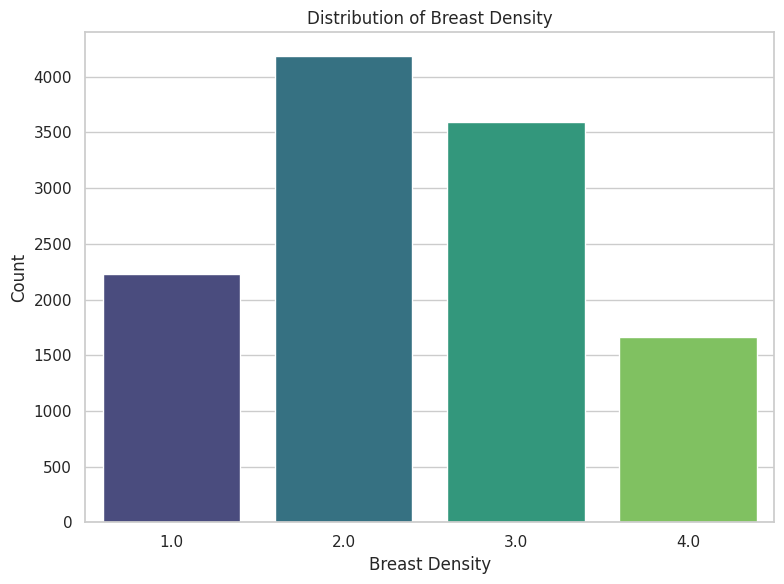

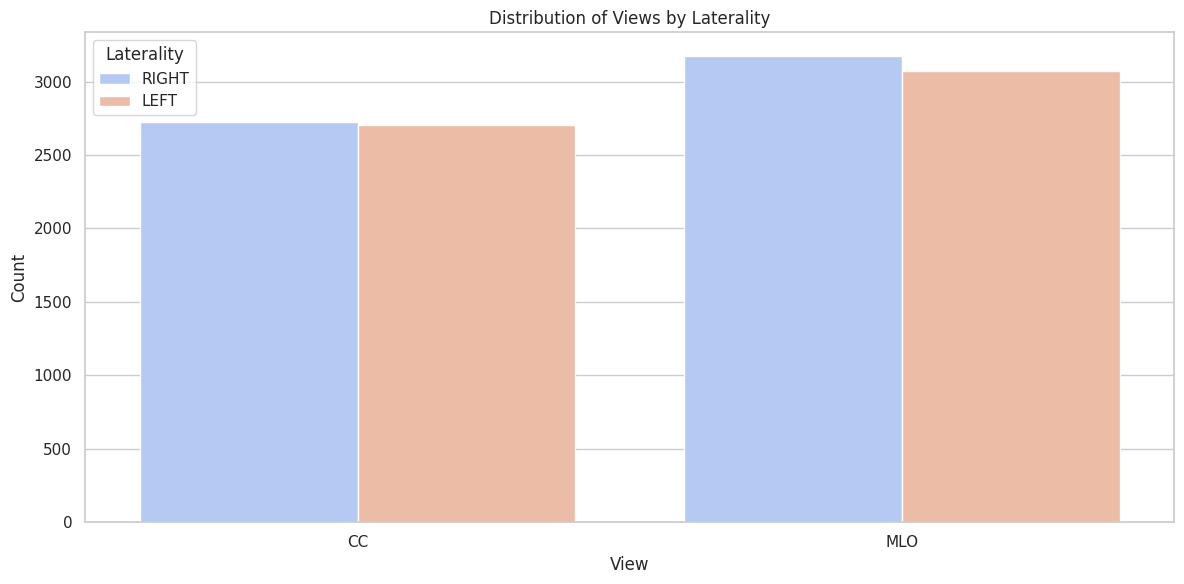

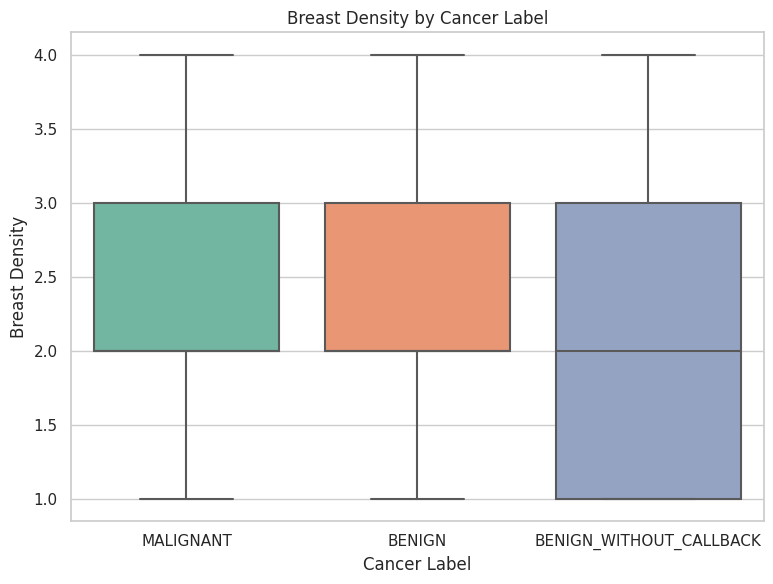

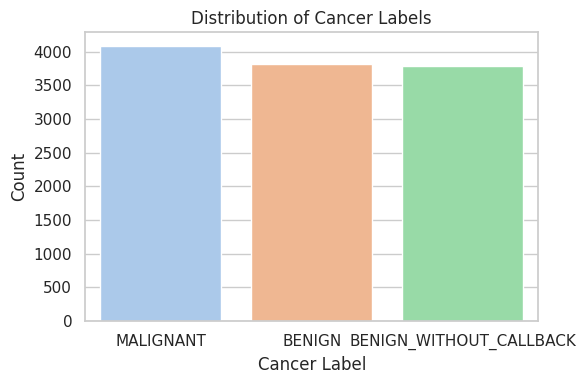

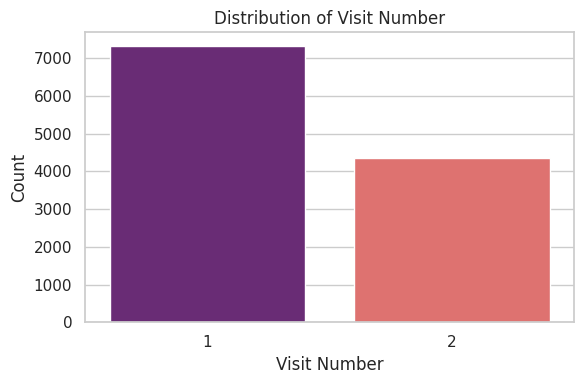

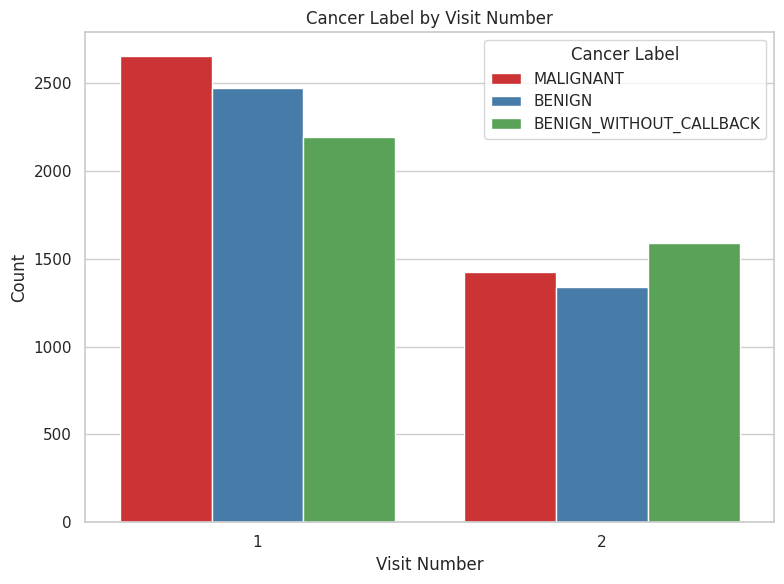

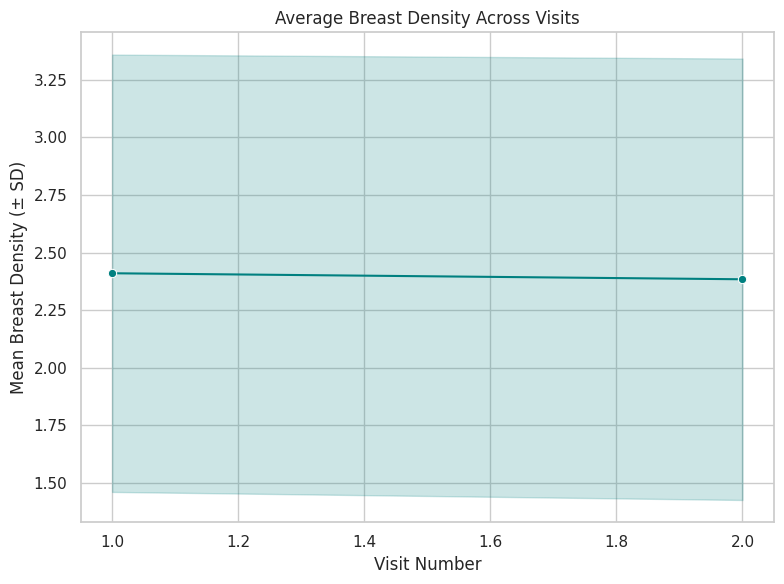

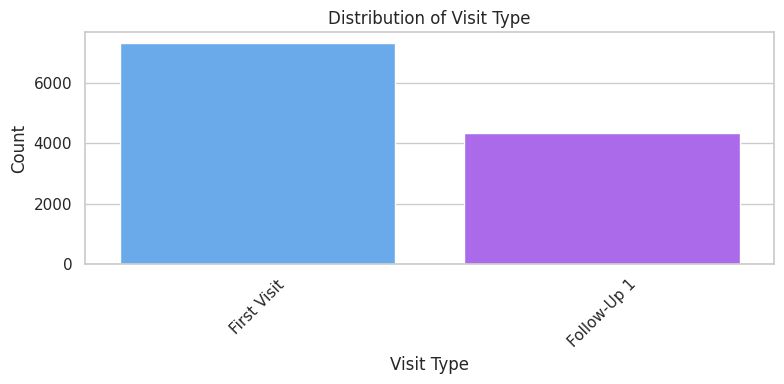

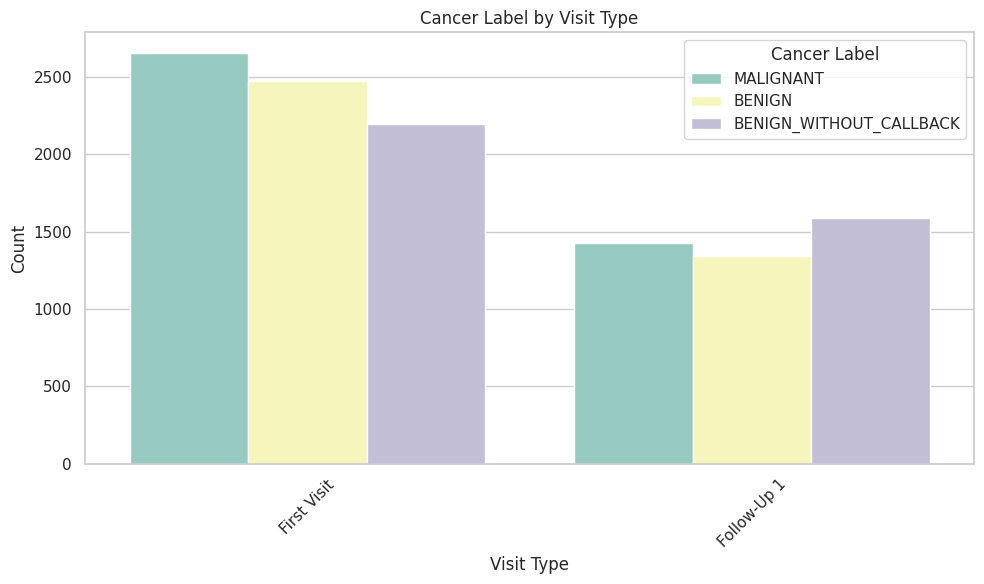

In [ ]:
# Part 2: Basic Charts (Enhanced for Visit Tracking)

def basic_charts(final_df):
    """
    Generate a set of basic charts and visualizations to explore
    the distribution of key variables in the final DataFrame,
    including visit tracking (visit_number, visit_type).
    """
    if final_df.empty:
        print("No data available for visualization.")
        return

    sns.set(style="whitegrid")  # Set seaborn style

    # -------------------------------------------------------------------------
    # 1. Distribution of breast_density
    # -------------------------------------------------------------------------
    plt.figure(figsize=(8, 6))
    sns.countplot(x='breast_density', data=final_df, palette='viridis')
    plt.title('Distribution of Breast Density')
    plt.xlabel('Breast Density')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # 2. Distribution by Laterality and View
    # -------------------------------------------------------------------------
    plt.figure(figsize=(12, 6))
    sns.countplot(x='View', hue='Laterality', data=final_df, palette='coolwarm')
    plt.title('Distribution of Views by Laterality')
    plt.xlabel('View')
    plt.ylabel('Count')
    plt.legend(title='Laterality')
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # 3. Breast Density by Cancer Label
    # -------------------------------------------------------------------------
    # Map numeric cancer_label to text labels
    cancer_label_mapping = {0: 'BENIGN', 1: 'MALIGNANT', 2: 'BENIGN_WITHOUT_CALLBACK'}
    final_df['Cancer Label'] = final_df['cancer_label'].map(cancer_label_mapping)

    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Cancer Label', y='breast_density', data=final_df, palette='Set2')
    plt.title('Breast Density by Cancer Label')
    plt.xlabel('Cancer Label')
    plt.ylabel('Breast Density')
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # 4. Distribution of Cancer Labels
    # -------------------------------------------------------------------------
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Cancer Label', data=final_df, palette='pastel')
    plt.title('Distribution of Cancer Labels')
    plt.xlabel('Cancer Label')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # 5. Distribution of visit_number
    # -------------------------------------------------------------------------
    # Shows how many visits (1st, 2nd, etc.) are in the dataset
    if 'visit_number' in final_df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(x='visit_number', data=final_df, palette='magma')
        plt.title('Distribution of Visit Number')
        plt.xlabel('Visit Number')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 6. Cancer Label by visit_number
    # -------------------------------------------------------------------------
    # Shows how pathology distribution changes across visits
    if 'visit_number' in final_df.columns:
        plt.figure(figsize=(8, 6))
        sns.countplot(x='visit_number', hue='Cancer Label', data=final_df, palette='Set1')
        plt.title('Cancer Label by Visit Number')
        plt.xlabel('Visit Number')
        plt.ylabel('Count')
        plt.legend(title='Cancer Label')
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 7. Breast Density vs. visit_number
    # -------------------------------------------------------------------------
    # (Optional) Illustrates changes in average breast density across visits
    if 'visit_number' in final_df.columns:
        plt.figure(figsize=(8, 6))
        sns.lineplot(
            x='visit_number',
            y='breast_density',
            data=final_df,
            estimator='mean',
            ci='sd',
            marker='o',
            color='teal'
        )
        plt.title('Average Breast Density Across Visits')
        plt.xlabel('Visit Number')
        plt.ylabel('Mean Breast Density (± SD)')
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 8. Distribution of visit_type (First Visit, Follow-Up, etc.)
    # -------------------------------------------------------------------------
    if 'visit_type' in final_df.columns:
        plt.figure(figsize=(8, 4))
        sns.countplot(x='visit_type', data=final_df, palette='cool')
        plt.title('Distribution of Visit Type')
        plt.xlabel('Visit Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 9. Cancer Label by visit_type (Optional)
    # -------------------------------------------------------------------------
    if 'visit_type' in final_df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(x='visit_type', hue='Cancer Label', data=final_df, palette='Set3')
        plt.title('Cancer Label by Visit Type')
        plt.xlabel('Visit Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.legend(title='Cancer Label')
        plt.tight_layout()
        plt.show()

    # Uncomment if you want to see a pair plot
    """
    # Optional Pair Plot
    sns.pairplot(final_df, vars=['breast_density', 'cancer_label', 'visit_number'],
                 hue='Cancer Label', palette='Set2')
    plt.suptitle('Pair Plot (Breast Density, Cancer Label, Visit Number)', y=1.02)
    plt.tight_layout()
    plt.show()
    """
basic_charts(final_df)

In [ ]:
# 1. Gather all possible .jpg cropped images in the dataset root
dataset_root_cropped = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/"
actual_cropped_files = []
for root_dir, dirs, files in os.walk(dataset_root_cropped):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            actual_cropped_files.append(os.path.abspath(os.path.join(root_dir, file)))

print(f"Total actual cropped images found: {len(actual_cropped_files)}")

# 2. Define a correction function for cropped images
def correct_cropped_image_path(rel_path):
    if pd.isna(rel_path):
        return None
    folder_id = os.path.basename(os.path.dirname(rel_path))
    for file_path in actual_cropped_files:
        if folder_id in file_path:
            return file_path
    return None

# 3. Apply the correction to final_df
final_df['cropped_image_path'] = final_df['cropped_image_path'].apply(correct_cropped_image_path)

# 4. Verify missing or invalid paths
missing_cropped = final_df['cropped_image_path'].isna().sum()
print(f"Missing 'cropped_image_path' after correction: {missing_cropped}")

# (Optional) Remove rows still missing a valid cropped image path
final_df = final_df[final_df['cropped_image_path'].notna()]

# 5. (Optional) Check file existence
final_df['cropped_image_exists'] = final_df['cropped_image_path'].apply(
    lambda x: os.path.exists(x) if pd.notna(x) else False
)

print("Cropped image path validity counts:")
print(final_df['cropped_image_exists'].value_counts())

final_df = final_df[final_df['cropped_image_exists'] == True]
final_df.drop(columns=['cropped_image_exists'], inplace=True)

print(f"Final record count after ensuring valid cropped paths: {len(final_df)}")

# 6. Display a sample to confirm
display(final_df.head(5))

Total actual cropped images found: 10237
Missing 'cropped_image_path' after correction: 5
Cropped image path validity counts:
cropped_image_exists
True    11674
Name: count, dtype: int64
Final record count after ensuring valid cropped paths: 11674


,PatientID,Laterality,View,StudyDate,cancer_label,breast_density,corrected_image_path,cropped_image_path,visit_number,visit_type,Cancer Label
2488,Calc-Training_P_00005_RIGHT_CC,RIGHT,CC,1970-01-01 00:00:00.020160807,1.0,3.0,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,1,First Visit,MALIGNANT
5891,Calc-Training_P_00005_RIGHT_CC_1,RIGHT,CC,1970-01-01 00:00:00.020170830,1.0,3.0,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,1,First Visit,MALIGNANT
5890,Calc-Training_P_00005_RIGHT_CC_1,RIGHT,CC,1970-01-01 00:00:00.020170906,1.0,3.0,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,2,Follow-Up 1,MALIGNANT
5163,Calc-Training_P_00005_RIGHT_MLO,RIGHT,MLO,1970-01-01 00:00:00.020160807,1.0,3.0,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,1,First Visit,MALIGNANT
3796,Calc-Training_P_00005_RIGHT_MLO_1,RIGHT,MLO,1970-01-01 00:00:00.020170830,1.0,3.0,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,/kaggle/input/cbis-ddsm-breast-cancer-image-da...,1,First Visit,MALIGNANT


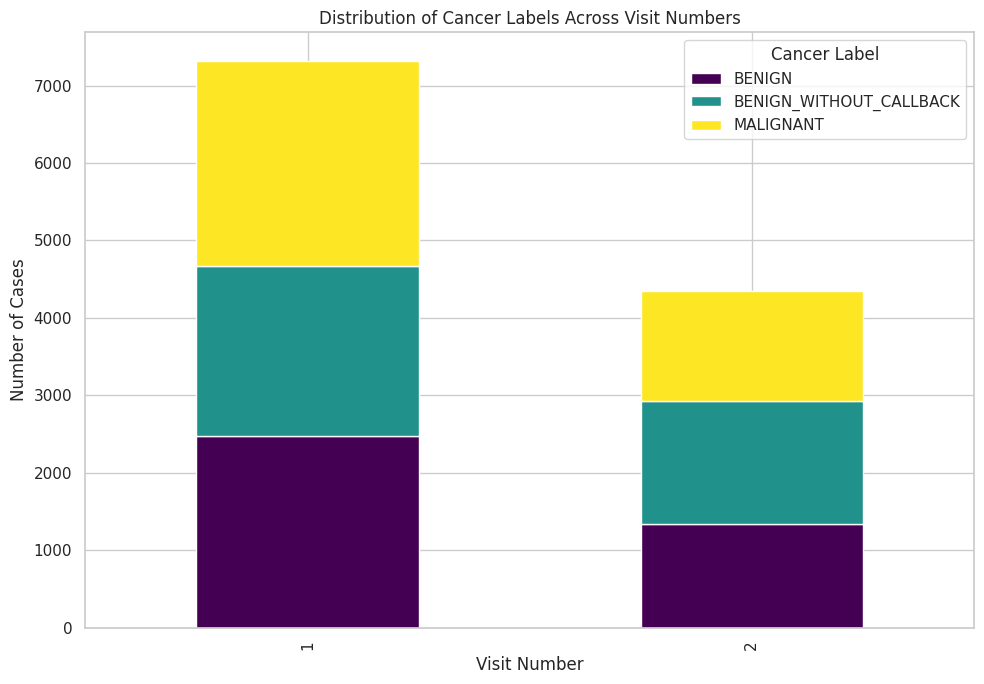

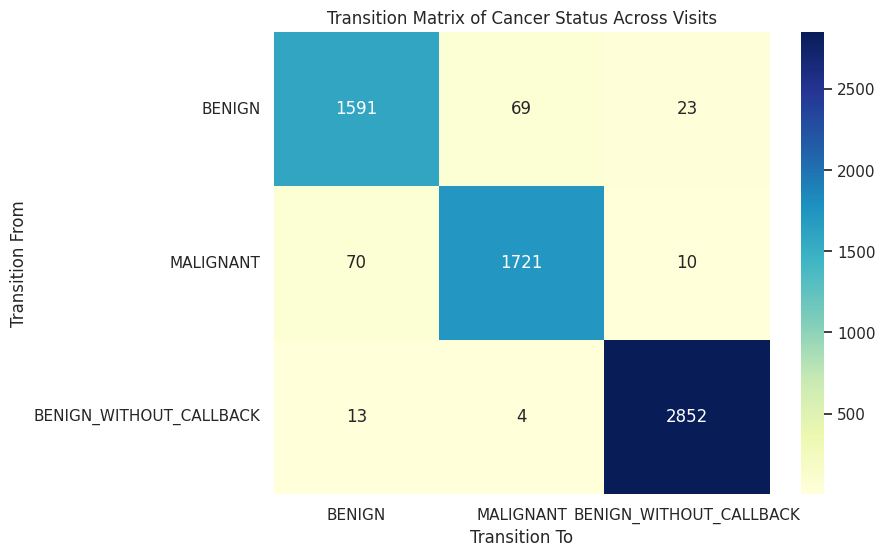

In [ ]:
def stacked_bar_cancer_over_visits(final_df):
    """
    Create a stacked bar chart showing the distribution of cancer labels across visit numbers.
    """
    # Map cancer labels to descriptive names
    cancer_label_mapping = {0: 'BENIGN', 1: 'MALIGNANT', 2: 'BENIGN_WITHOUT_CALLBACK'}
    final_df['Cancer Label'] = final_df['cancer_label'].map(cancer_label_mapping)

    # Aggregate data
    agg_data = final_df.groupby(['visit_number', 'Cancer Label']).size().reset_index(name='count')

    # Pivot for stacking
    pivot_data = agg_data.pivot(index='visit_number', columns='Cancer Label', values='count').fillna(0)

    # Plot stacked bar chart
    pivot_data.plot(kind='bar', stacked=True, figsize=(10,7), colormap='viridis')
    plt.title('Distribution of Cancer Labels Across Visit Numbers')
    plt.xlabel('Visit Number')
    plt.ylabel('Number of Cases')
    plt.legend(title='Cancer Label')
    plt.tight_layout()
    plt.show()

def transition_matrix_heatmap(final_df):
    """
    Create a heatmap to visualize the transition frequencies between cancer statuses.
    """
    # Ensure 'cancer_label' is integer
    final_df['cancer_label'] = final_df['cancer_label'].astype(int)

    # Sort DataFrame by PatientID and StudyDate
    final_df_sorted = final_df.sort_values(['PatientID', 'StudyDate'])

    # Group by PatientID
    grouped = final_df_sorted.groupby('PatientID')

    # Initialize transition counts
    transition_counts = pd.DataFrame(0, index=['BENIGN', 'MALIGNANT', 'BENIGN_WITHOUT_CALLBACK'],
                                    columns=['BENIGN', 'MALIGNANT', 'BENIGN_WITHOUT_CALLBACK'])

    for patient_id, group in grouped:
        group = group.sort_values('StudyDate')
        labels = group['cancer_label'].tolist()

        for i in range(len(labels) -1):
            src = labels[i]
            tgt = labels[i+1]
            src_label = 'BENIGN' if src == 0 else 'MALIGNANT' if src ==1 else 'BENIGN_WITHOUT_CALLBACK'
            tgt_label = 'BENIGN' if tgt == 0 else 'MALIGNANT' if tgt ==1 else 'BENIGN_WITHOUT_CALLBACK'
            transition_counts.at[src_label, tgt_label] +=1

    # Plot heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(transition_counts, annot=True, fmt='d', cmap='YlGnBu')
    plt.title('Transition Matrix of Cancer Status Across Visits')
    plt.xlabel('Transition To')
    plt.ylabel('Transition From')
    plt.show()

def create_interactive_sankey(final_df, max_visits=2):
    """
    Create an interactive Sankey diagram showing transitions up to a specified number of visits.

    Parameters:
        final_df (pd.DataFrame): The final cleaned DataFrame.
        max_visits (int): The number of visits to include in the Sankey diagram.
    """
    # Filter for patients with at least 'max_visits' visits
    patient_visit_counts = final_df['PatientID'].value_counts()
    eligible_patients = patient_visit_counts[patient_visit_counts >= max_visits].index
    filtered_df = final_df[final_df['PatientID'].isin(eligible_patients)]

    # Sort by PatientID and StudyDate
    filtered_df = filtered_df.sort_values(['PatientID', 'StudyDate'])

    # Initialize lists for nodes and links
    label_list = []
    source = []
    target = []
    value = []

    # Dictionary to map label to index
    label_to_index = {}

    for patient_id, group in filtered_df.groupby('PatientID'):
        group = group.sort_values('StudyDate').head(max_visits)
        labels = group['cancer_label'].tolist()

        for i in range(len(labels) -1):
            src_label = f"Visit {i+1} - {cancer_label_mapping[labels[i]]}"
            tgt_label = f"Visit {i+2} - {cancer_label_mapping[labels[i+1]]}"

            # Add labels to list if not already present
            for lbl in [src_label, tgt_label]:
                if lbl not in label_to_index:
                    label_to_index[lbl] = len(label_list)
                    label_list.append(lbl)

            # Append to Sankey links
            src_idx = label_to_index[src_label]
            tgt_idx = label_to_index[tgt_label]
            source.append(src_idx)
            target.append(tgt_idx)
            value.append(1)  # Increment by 1 for each occurrence

    # Aggregate link values
    link_df = pd.DataFrame({'source': source, 'target': target, 'value': value})
    link_df = link_df.groupby(['source', 'target']).sum().reset_index()

    # Create Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=label_list,
            color=["lightblue", "lightcoral", "lightgreen"] * (len(label_list)//3 +1)
        ),
        link=dict(
            source=link_df['source'],
            target=link_df['target'],
            value=link_df['value']
        ))])

    fig.update_layout(title_text="Interactive Sankey Diagram of Cancer Status Transitions Across Visits", font_size=10)
    fig.show()

# Define cancer label mapping
cancer_label_mapping = {0: 'BENIGN', 1: 'MALIGNANT', 2: 'BENIGN_WITHOUT_CALLBACK'}


# Execute the stacked bar chart
stacked_bar_cancer_over_visits(final_df)

# Execute the transition matrix heatmap
transition_matrix_heatmap(final_df)

# Execute the interactive Sankey diagram
create_interactive_sankey(final_df, max_visits=2)

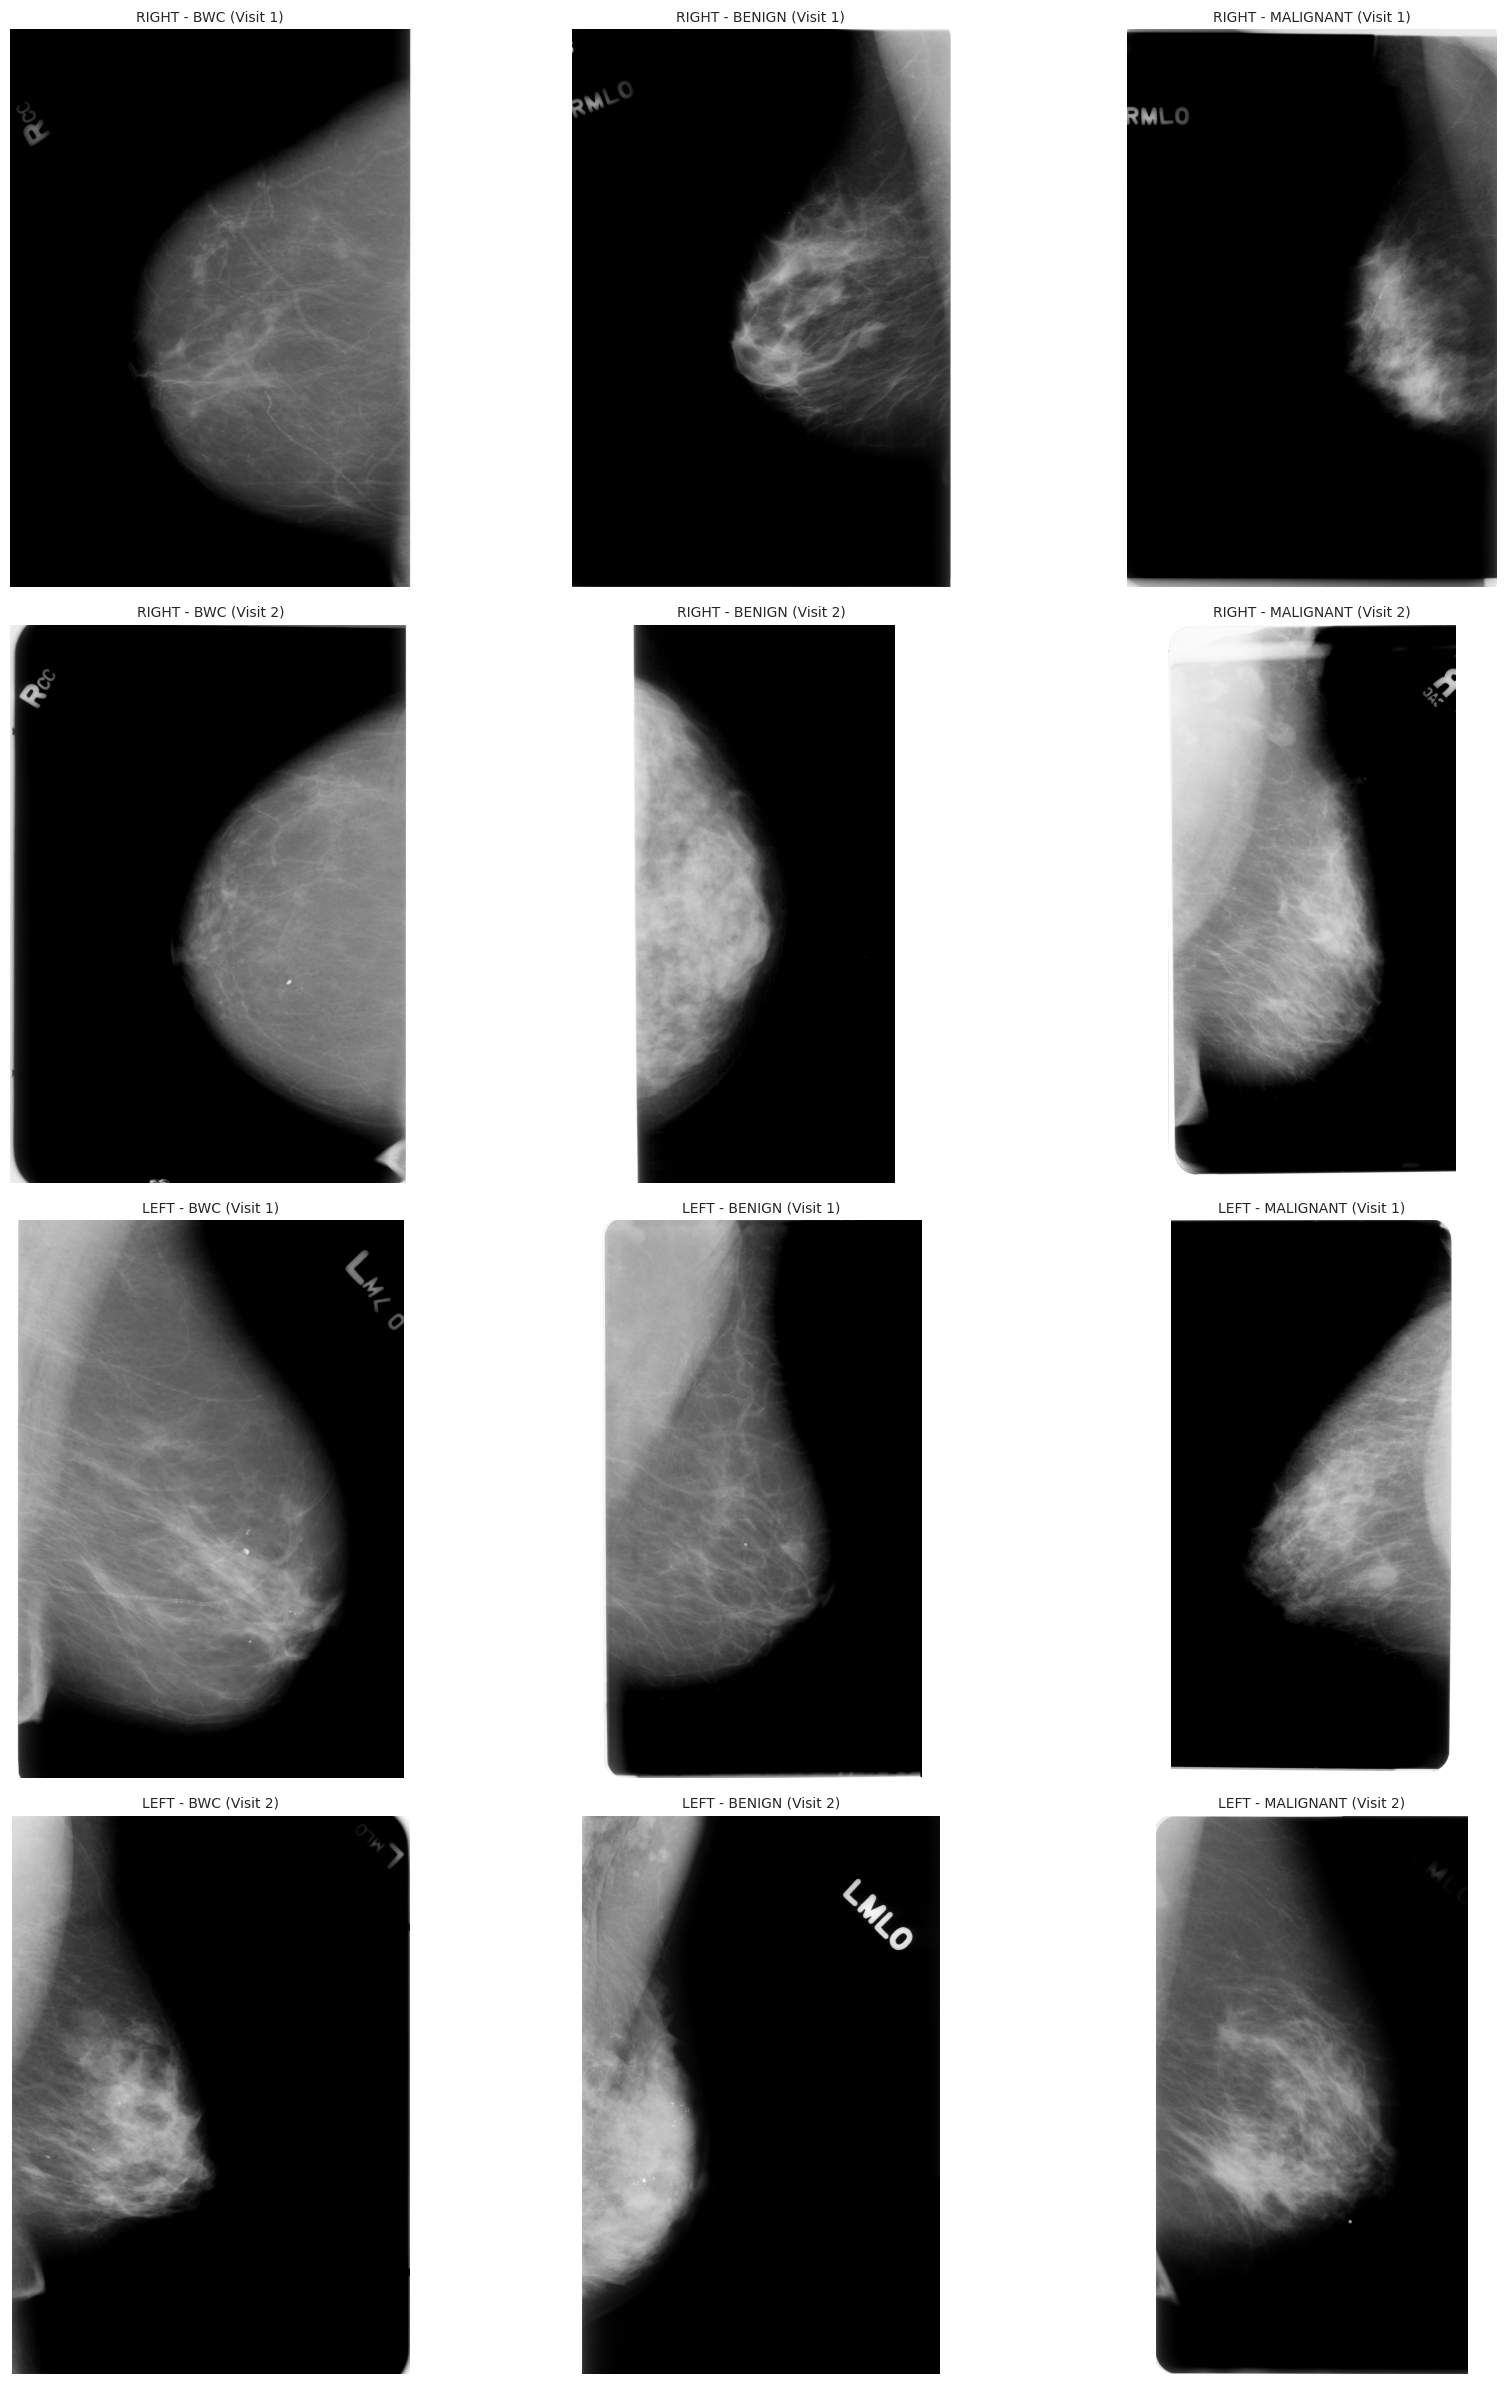

In [ ]:
# Part 3: Image Visualization (Individual and Subplots)

# -------------------------------------------------
# Helper function to map numeric labels to text
# -------------------------------------------------
def map_cancer_label(label):
    """
    Maps a numeric cancer label to a human-readable string.
    0.0 -> BENIGN
    1.0 -> MALIGNANT
    2.0 -> BWC (Benign Without Callback)
    """
    return {0.0: 'BENIGN', 1.0: 'MALIGNANT', 2.0: 'BWC'}.get(label, 'UNKNOWN')

# -------------------------------------------------
# Helper function to load and display images
# -------------------------------------------------
def plot_image(ax, image_path, title):
    """
    Tries to load an image from the given path and display it.
    If not found, displays a placeholder text.
    """
    try:
        img = mpimg.imread(image_path)
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        ax.set_title(title, fontsize=10)
    except Exception as e:
        ax.text(0.5, 0.5, 'Image Not Found', fontsize=8, ha='center')
        ax.axis('off')

# -------------------------------------------------
# Helper function to sample images by Laterality and Cancer Label
# -------------------------------------------------
def sample_images(df, laterality, cancer_label, n=2):
    """
    Returns a random sample of 'n' rows from df
    matching the given laterality and cancer_label.
    """
    subset = df[(df['Laterality'] == laterality) & (df['cancer_label'] == cancer_label)]
    if len(subset) < n:
        print(f"Warning: Only {len(subset)} images found for {laterality} - {map_cancer_label(cancer_label)}.")
        return subset
    return subset.sample(n, random_state=42)  # Set random_state for reproducibility

# -------------------------------------------------
# Main function to visualize a grid of sampled images
# -------------------------------------------------
def visualize_sample_images(final_df):
    """
    Creates a 4x3 grid of images:
    - 2 rows for RIGHT samples (BWC, Benign, Malignant)
    - 2 rows for LEFT samples (BWC, Benign, Malignant)
    Each category is sampled twice, for a total of 12 images.
    Ensures that different images are displayed in both rows.
    """
    # Define the categories
    categories = [
        ('RIGHT', 2.0),  # BWC
        ('RIGHT', 0.0),  # BENIGN
        ('RIGHT', 1.0),  # MALIGNANT
        ('LEFT', 2.0),   # BWC
        ('LEFT', 0.0),   # BENIGN
        ('LEFT', 1.0)    # MALIGNANT
    ]

    # Initialize a dictionary to hold samples per category
    samples = {}

    for cat in categories:
        sampled = sample_images(final_df, cat[0], cat[1], n=2)
        samples[cat] = sampled

    # Create a 4x3 grid
    fig, axes = plt.subplots(4, 3, figsize=(18, 24))

    # Assign images to grid
    for row in range(4):
        for col in range(3):
            # Determine the category index
            category_idx = col  # 0,1,2 for BWC, BENIGN, MALIGNANT
            if row < 2:
                laterality = 'RIGHT'
            else:
                laterality = 'LEFT'

            cancer_label = categories[col][1]  # Get cancer_label based on column
            cat = (laterality, cancer_label)

            # Determine sample index
            sample_idx = row % 2  # 0 for first row, 1 for second row

            # Get the sample
            if len(samples.get(cat, [])) > sample_idx:
                sample_row = samples[cat].iloc[sample_idx]
                label_text = map_cancer_label(cancer_label)
                title = f"{laterality} - {label_text} (Visit {sample_idx +1})"
                plot_image(axes[row, col], sample_row['corrected_image_path'], title)
            else:
                axes[row, col].text(0.5, 0.5, 'No Sample Found', fontsize=8, ha='center')
                axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# Execute the image visualization
visualize_sample_images(final_df)

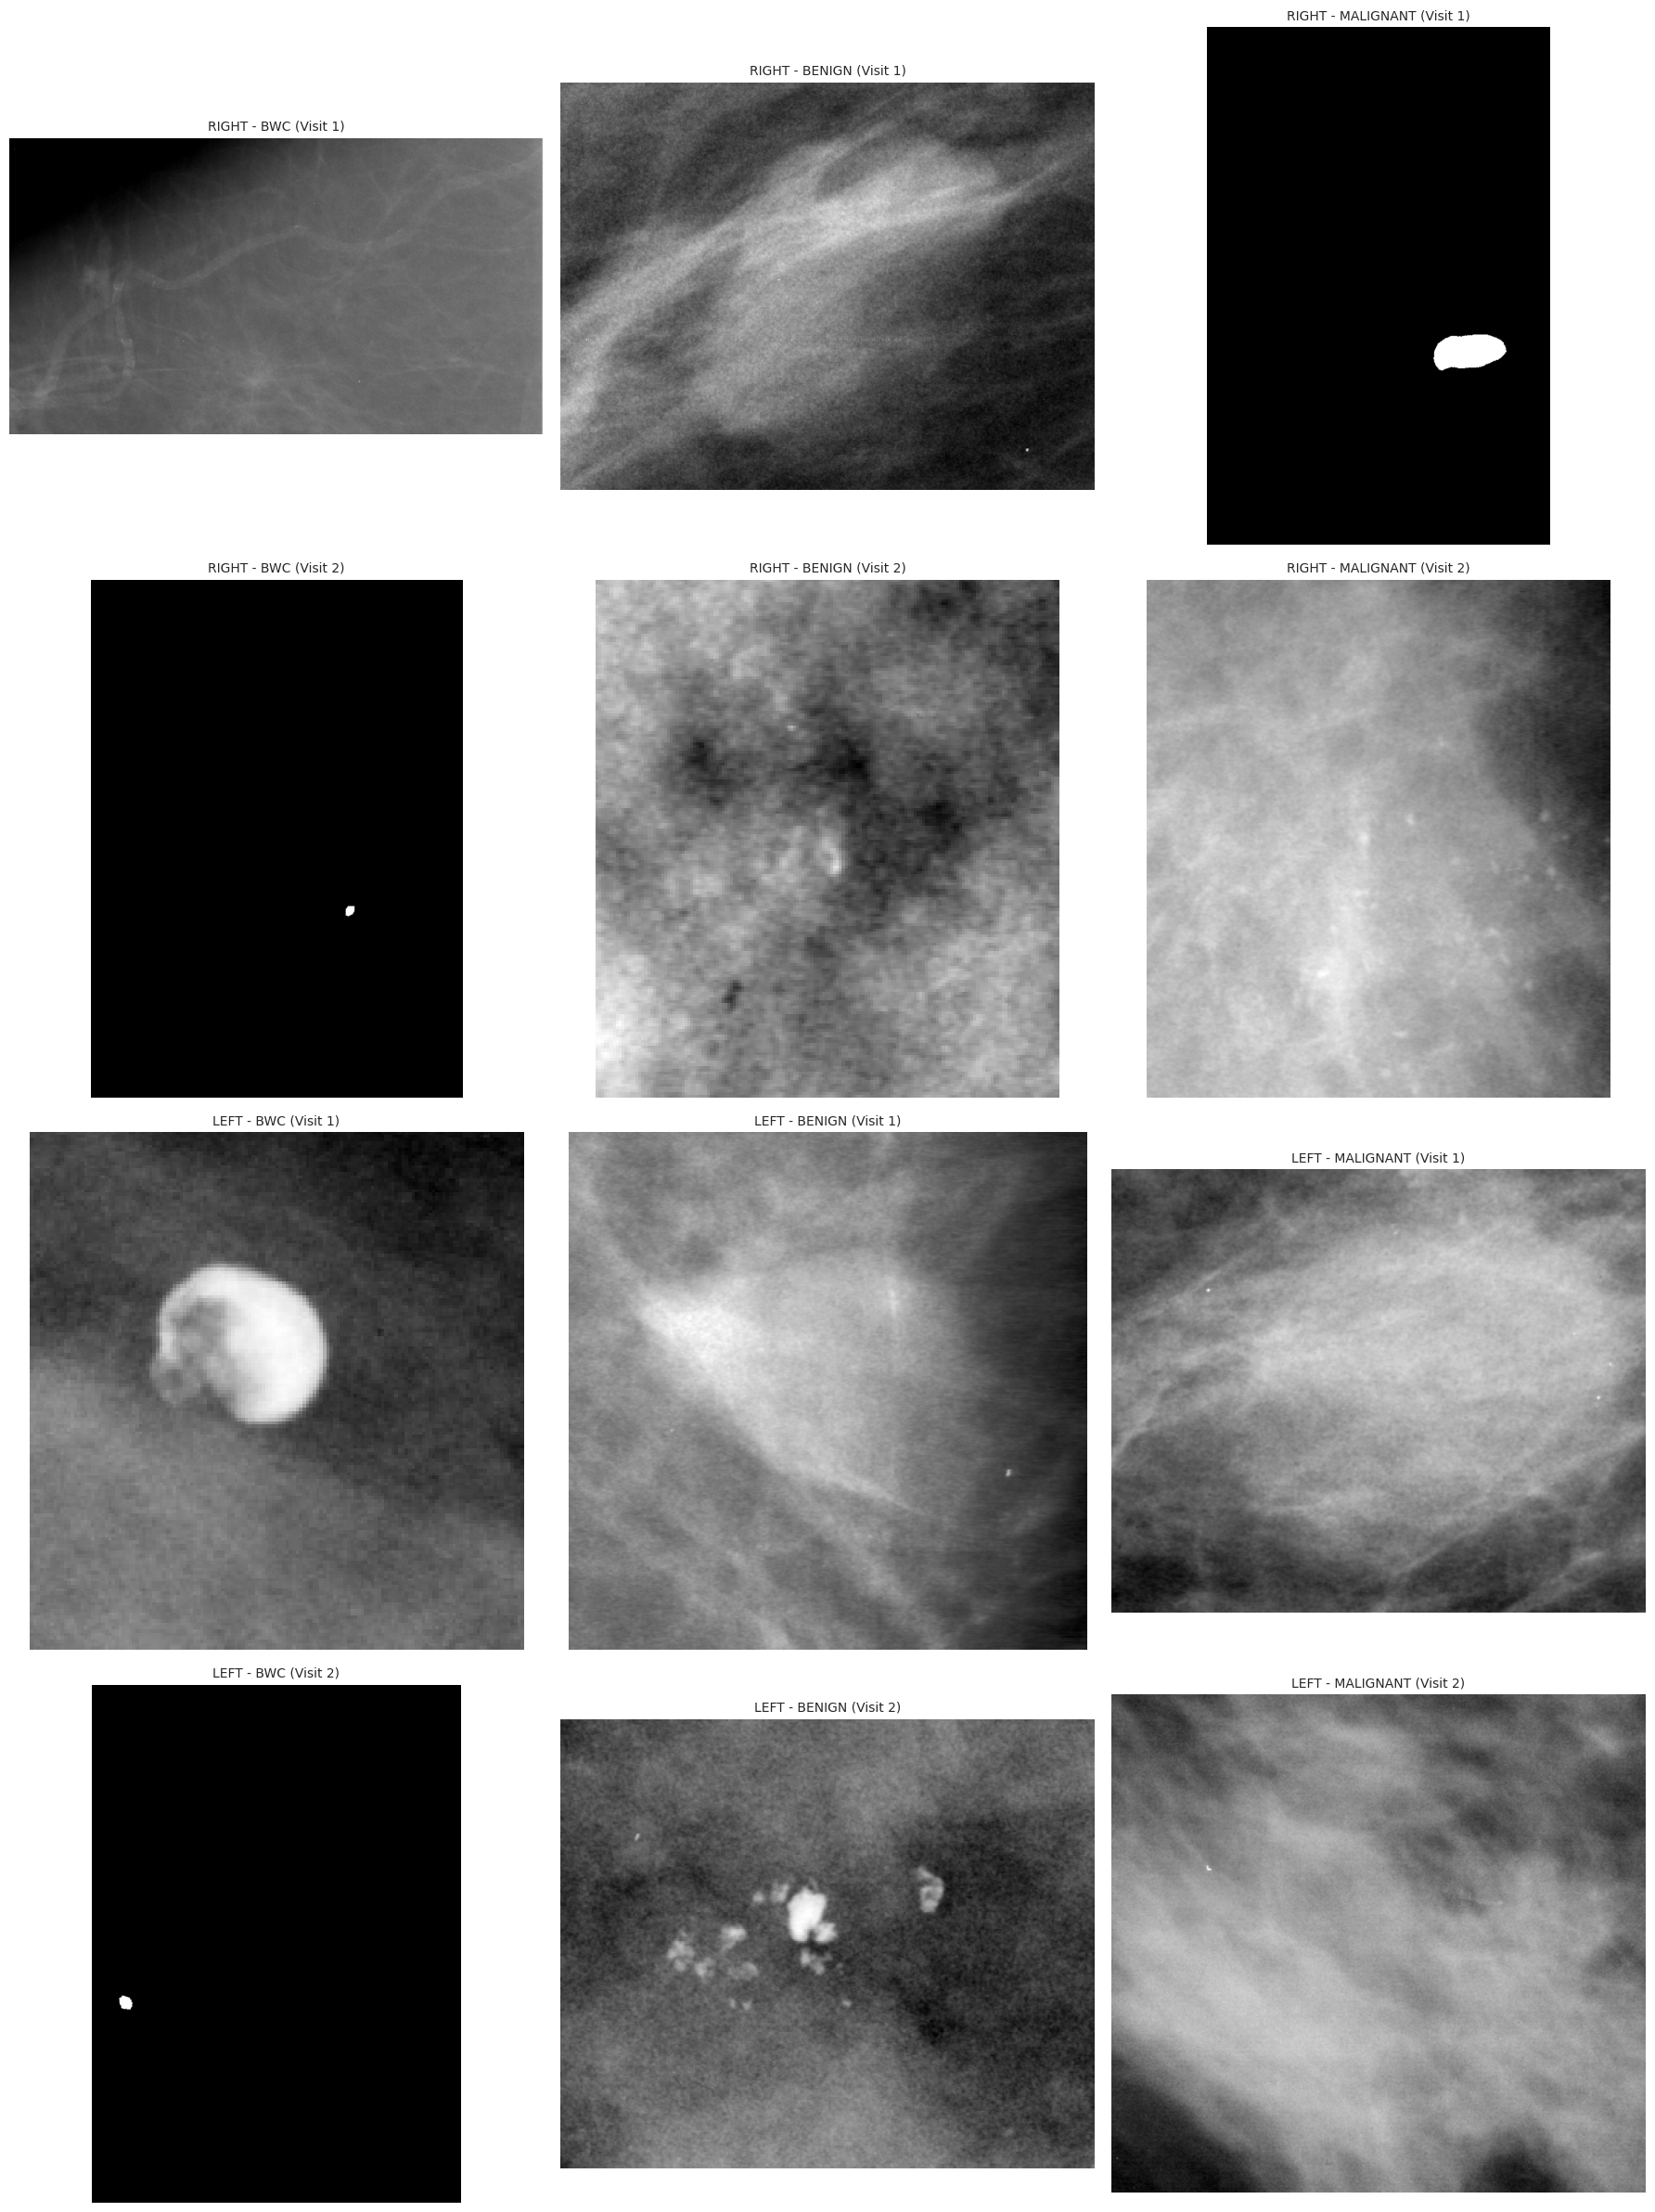

In [ ]:
# -------------------------------------------------
# Helper function to map numeric labels to text
# -------------------------------------------------
def map_cancer_label(label):
    """
    Maps a numeric cancer label to a human-readable string.
    0.0 -> BENIGN
    1.0 -> MALIGNANT
    2.0 -> BWC (Benign Without Callback)
    """
    return {0.0: 'BENIGN', 1.0: 'MALIGNANT', 2.0: 'BWC'}.get(label, 'UNKNOWN')

# -------------------------------------------------
# Helper function to load and display images
# -------------------------------------------------
def plot_image(ax, image_path, title):
    """
    Tries to load an image from the given path and display it.
    If not found, displays a placeholder text.
    """
    try:
        img = mpimg.imread(image_path)
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        ax.set_title(title, fontsize=10)
    except Exception as e:
        ax.text(0.5, 0.5, 'Image Not Found', fontsize=8, ha='center')
        ax.axis('off')

# -------------------------------------------------
# Helper function to sample images by Laterality and Cancer Label
# -------------------------------------------------
def sample_images(df, laterality, cancer_label, n=2):
    """
    Returns a random sample of 'n' rows from df
    matching the given laterality and cancer_label.
    """
    subset = df[(df['Laterality'] == laterality) & (df['cancer_label'] == cancer_label)]
    if len(subset) < n:
        print(f"Warning: Only {len(subset)} images found for {laterality} - {map_cancer_label(cancer_label)}.")
        return subset
    return subset.sample(n, random_state=42)  # Set random_state for reproducibility

# -------------------------------------------------
# Main function to visualize a grid of sampled cropped images
# -------------------------------------------------
def visualize_cropped_sample_images(final_df):
    """
    Creates a 4x3 grid of cropped images:
    - 2 rows for RIGHT samples (BWC, Benign, Malignant)
    - 2 rows for LEFT samples (BWC, Benign, Malignant)
    Each category is sampled twice, for a total of 12 images.
    Ensures that different images are displayed in both rows.
    """
    # Define the categories
    categories = [
        ('RIGHT', 2.0),  # BWC
        ('RIGHT', 0.0),  # BENIGN
        ('RIGHT', 1.0),  # MALIGNANT
        ('LEFT', 2.0),   # BWC
        ('LEFT', 0.0),   # BENIGN
        ('LEFT', 1.0)    # MALIGNANT
    ]

    # Initialize a dictionary to hold samples per category
    samples = {}

    for cat in categories:
        sampled = sample_images(final_df, cat[0], cat[1], n=2)
        samples[cat] = sampled

    # Create a 4x3 grid
    fig, axes = plt.subplots(4, 3, figsize=(18, 24))

    # Assign images to grid
    for row in range(4):
        for col in range(3):
            # Determine the category index
            category_idx = col  # 0,1,2 for BWC, BENIGN, MALIGNANT
            if row < 2:
                laterality = 'RIGHT'
            else:
                laterality = 'LEFT'

            cancer_label = categories[col][1]  # Get cancer_label based on column
            cat = (laterality, cancer_label)

            # Determine sample index
            sample_idx = row % 2  # 0 for first row, 1 for second row

            # Get the sample
            if len(samples.get(cat, [])) > sample_idx:
                sample_row = samples[cat].iloc[sample_idx]
                label_text = map_cancer_label(cancer_label)
                title = f"{laterality} - {label_text} (Visit {sample_idx +1})"
                plot_image(axes[row, col], sample_row['cropped_image_path'], title)
            else:
                axes[row, col].text(0.5, 0.5, 'No Sample Found', fontsize=8, ha='center')
                axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# Execute the cropped image visualization
visualize_cropped_sample_images(final_df)

In [ ]:

def preprocess_dicom(dicom_df):
    """
    Clean and standardize the DICOM DataFrame.

    Steps:
    - Filter out 'Test' dataset records
    - Clean and standardize 'PatientID'
    - Extract 'CorePatientID' using regex (e.g., "P_00001")
    - Extract 'Laterality' (LEFT or RIGHT)
    - Extract 'View' (CC or MLO)
    - Parse StudyDate as datetime
    """
    logging.info("Preprocessing DICOM DataFrame...")

    # 1. Filter out TEST dataset records
    original_count = dicom_df.shape[0]
    dicom_df = dicom_df[~dicom_df['PatientID'].str.contains('Test', case=False, na=False)]
    filtered_count = dicom_df.shape[0]
    logging.info(f"Filtered out {original_count - filtered_count} 'Test' records. Remaining records: {filtered_count}")

    # 2. Clean and standardize PatientID
    dicom_df['CleanPatientID'] = (
        dicom_df['PatientID']
        .apply(lambda x: re.sub(r'(_\d+)$', '', x))  # Remove suffix like _1
        .str.strip()
        .str.upper()
    )

    # 3. Extract CorePatientID (e.g., P_00001)
    dicom_df['CorePatientID'] = dicom_df['CleanPatientID'].apply(
        lambda x: re.search(r'(P_\d+)', x).group(1) if pd.notnull(x) and re.search(r'(P_\d+)', x) else x
    )

    # 4. Extract Laterality
    dicom_df['Laterality'] = dicom_df['CleanPatientID'].apply(
        lambda x: 'LEFT' if 'LEFT' in x else 'RIGHT' if 'RIGHT' in x else None
    )

    # 5. Extract View
    dicom_df['View'] = dicom_df['CleanPatientID'].apply(
        lambda x: 'CC' if 'CC' in x else 'MLO' if 'MLO' in x else None
    )

    # 6. Parse StudyDate as datetime (coerce errors to NaT if invalid)
    if 'StudyDate' in dicom_df.columns:
        dicom_df['StudyDate'] = pd.to_datetime(dicom_df['StudyDate'], errors='coerce')

    logging.info("DICOM DataFrame preprocessing complete.\n")
    return dicom_df

# ------------------------------------------------------------------------------
# PATHOLOGY PREPROCESSING
# ------------------------------------------------------------------------------
def preprocess_pathology(df, pathology_type):
    """
    Clean and standardize a pathology DataFrame (CALC or MASS).

    Steps:
    - Standardize relevant text columns (patient_id, left or right breast, image view)
    - Rename columns for consistency based on pathology type
    """
    logging.info(f"Preprocessing {pathology_type.upper()} Pathology DataFrame...")

    # 1. Standardize relevant columns
    df['patient_id'] = df['patient_id'].str.strip().str.upper()
    df['left or right breast'] = df['left or right breast'].str.strip().str.upper()
    df['image view'] = df['image view'].str.strip().str.upper()

    # 2. Define rename mappings based on pathology type
    rename_map = {
        'breast density': 'breast_density',
        'image file path': 'corrected_image_path',
        'cropped image file path': 'cropped_image_path'
    }

    # Additional mappings for MASS pathology
    if pathology_type.lower() == 'mass':
        additional_renames = {
            'mass shape': 'mass_shape',
            'mass margins': 'mass_margins',
            # Add other relevant columns if needed
        }
        rename_map.update(additional_renames)

    # Rename the columns
    df.rename(columns=rename_map, inplace=True)

    logging.info(f"Preprocessed {pathology_type.upper()} DataFrame with {df.shape[0]} records.\n")
    return df

# ------------------------------------------------------------------------------
# DATA EXPLORATION BEFORE MERGING
# ------------------------------------------------------------------------------
def explore_preprocessed_datasets(dicom_df, calc_df, mass_df):
    """
    (Currently commented out for brevity, but can be used to explore DataFrames
     before merging if needed.)
    """
    print("=== Unique Values in DICOM DataFrame ===")
    for column in dicom_df.columns:
        unique_vals = dicom_df[column].nunique()
        print(f"{column}: {unique_vals} unique values")
    print("\n")

    print("=== Unique Values in CALC Pathology DataFrame ===")
    for column in calc_df.columns:
        unique_vals = calc_df[column].nunique()
        print(f"{column}: {unique_vals} unique values")
    print("\n")

    print("=== Unique Values in MASS Pathology DataFrame ===")
    for column in mass_df.columns:
        unique_vals = mass_df[column].nunique()
        print(f"{column}: {unique_vals} unique values")
    print("\n")

# ------------------------------------------------------------------------------
# MERGE FUNCTIONS
# ------------------------------------------------------------------------------
def merge_pathology(dicom_df, pathology_df, pathology_type):
    """
    Merge a pathology DataFrame with the DICOM DataFrame based on common keys:
    - CorePatientID with patient_id
    - Laterality with left or right breast
    - View with image view

    Returns:
        pd.DataFrame: Merged DataFrame
    """
    logging.info(f"Merging DICOM DataFrame with {pathology_type.upper()} Pathology DataFrame...")

    # Define the columns to merge based on pathology_type
    if pathology_type.lower() == 'mass':
        # Include 'mass_shape' for MASS pathology
        merge_columns = ['patient_id', 'breast_density', 'left or right breast', 'image view',
                        'pathology', 'corrected_image_path', 'cropped_image_path', 'mass_shape']
    else:
        # Exclude 'mass_shape' for CALC pathology
        merge_columns = ['patient_id', 'breast_density', 'left or right breast', 'image view',
                        'pathology', 'corrected_image_path', 'cropped_image_path']

    # Check if all merge_columns exist in pathology_df
    missing_cols = [col for col in merge_columns if col not in pathology_df.columns]
    if missing_cols:
        logging.warning(f"The following columns are missing in the {pathology_type.upper()} Pathology DataFrame and will be ignored: {missing_cols}")
        merge_columns = [col for col in merge_columns if col in pathology_df.columns]

    # Perform the merge
    merged_df = dicom_df.merge(
        pathology_df[merge_columns],
        left_on=['CorePatientID', 'Laterality', 'View'],
        right_on=['patient_id', 'left or right breast', 'image view'],
        how='left',
        suffixes=('', f'_{pathology_type}')
    )

    logging.info(f"Merged {pathology_type.upper()} DataFrame: {merged_df.shape[0]} records.\n")
    return merged_df

def combine_and_clean(calc_merged, mass_merged, dicom_df, calc_df_processed, mass_df_processed):
    """
    Combines merged CALC and MASS DataFrames and fills missing pathology data.
    Also maps pathology to numeric 'cancer_label'.

    Returns:
        pd.DataFrame: Combined and partially cleaned DataFrame
    """
    logging.info("Combining CALC and MASS Merged DataFrames...")

    # Combine CALC and MASS DataFrames
    combined_df = pd.concat([calc_merged, mass_merged], axis=0).reset_index(drop=True)
    logging.info(f"Combined DataFrame: {combined_df.shape[0]} records.\n")

    # Create fallback merges for missing 'pathology'
    logging.info("Filling missing 'pathology' values using fallback merges...")

    # Fallback for CALC using processed DataFrame
    fallback_calc = dicom_df.merge(
        calc_df_processed[['patient_id', 'pathology', 'cropped_image_path']],
        left_on='CorePatientID',
        right_on='patient_id',
        how='left'
    )

    # Fallback for MASS using processed DataFrame
    fallback_mass = dicom_df.merge(
        mass_df_processed[['patient_id', 'pathology', 'cropped_image_path']],
        left_on='CorePatientID',
        right_on='patient_id',
        how='left'
    )

    # Fill missing 'pathology'
    combined_df['pathology'] = combined_df['pathology'].fillna(fallback_calc['pathology'])
    combined_df['pathology'] = combined_df['pathology'].fillna(fallback_mass['pathology'])

    # Ensure 'cropped_image_path' exists
    if 'cropped_image_path' not in combined_df.columns:
        combined_df['cropped_image_path'] = np.nan

    # Fill missing 'cropped_image_path'
    combined_df['cropped_image_path'] = combined_df['cropped_image_path'].fillna(fallback_calc['cropped_image_path'])
    combined_df['cropped_image_path'] = combined_df['cropped_image_path'].fillna(fallback_mass['cropped_image_path'])

    # Map pathology to cancer labels
    pathology_mapping = {
        'MALIGNANT': 1,
        'BENIGN': 0,
        'BENIGN_WITHOUT_CALLBACK': 2
    }
    combined_df['cancer_label'] = combined_df['pathology'].map(pathology_mapping)

    logging.info("Combined DataFrame cleaning complete.\n")
    return combined_df

def finalize_dataframe(combined_df):
    """
    Select and order the final columns for the DataFrame, then incorporate
    visit tracking (visit_number and visit_type) using StudyDate.

    Steps:
    - Drop records where StudyDate is missing (if available)
    - Sort by (PatientID, StudyDate)
    - Assign 'visit_number' using group rank
    - Create 'visit_type' label: 'First Visit' or 'Follow-Up #'
    - Return final DataFrame with relevant columns
    """
    logging.info("Finalizing the DataFrame with selected columns...")

    # 1. Ensure StudyDate is in datetime format; if missing, skip
    if 'StudyDate' in combined_df.columns:
        combined_df['StudyDate'] = pd.to_datetime(combined_df['StudyDate'], errors='coerce')

        # 2. Drop records with missing StudyDate
        combined_df.dropna(subset=['StudyDate'], inplace=True)

        # 3. Sort by PatientID and StudyDate
        combined_df.sort_values(by=['PatientID', 'StudyDate'], inplace=True)

        # 4. Assign sequential visit numbers (rank)
        combined_df['visit_number'] = combined_df.groupby('PatientID')['StudyDate'].rank(method='dense').astype(int)

        # 5. Create descriptive visit_type label
        combined_df['visit_type'] = combined_df['visit_number'].apply(
            lambda x: 'First Visit' if x == 1 else f'Follow-Up {x - 1}'
        )
    else:
        # If no StudyDate, assign default visit columns
        combined_df['visit_number'] = 1
        combined_df['visit_type'] = 'First Visit'

    # 6. Determine final columns, including 'cropped_image_path' and 'mass_shape' if exists
    final_columns = [
        'PatientID',
        'Laterality',
        'View',
        'StudyDate',       # Include the date for reference
        'cancer_label',
        'breast_density',
        'corrected_image_path',
        'cropped_image_path',  # Newly added column
        'visit_number',
        'visit_type',
        'mass_shape'  # Include 'mass_shape' if it exists
    ]

    # 7. Add missing columns with default None values if they don't exist
    for col in final_columns:
        if col not in combined_df.columns:
            combined_df[col] = None

    # 8. Create the final DataFrame
    final_df = combined_df[final_columns].copy()

    logging.info(f"Final DataFrame contains {final_df.shape[0]} records with columns: {final_columns}\n")
    return final_df

# ------------------------------------------------------------------------------
# MAIN DATA CLEANING WORKFLOW
# ------------------------------------------------------------------------------
def data_cleaning_workflow():
    """
    High-level function to execute the entire data cleaning pipeline:
    1. Load
    2. Initial Exploration
    3. Preprocess DICOM
    4. Preprocess CALC/MASS
    5. Explore Preprocessed DataFrames
    6. Merge
    7. Combine & Clean
    8. Finalize

    Returns:
        final_df (pd.DataFrame): The final cleaned DataFrame
        dicom_df (pd.DataFrame): Preprocessed DICOM DataFrame
        calc_df_processed (pd.DataFrame): Preprocessed CALC DataFrame
        mass_df_processed (pd.DataFrame): Preprocessed MASS DataFrame
    """
    # 1. Load datasets
    dicom_df, calc_df, mass_df = load_datasets()

    # 2. Initial Exploration of Loaded Datasets (commented out by default)
    explore_datasets(dicom_df, calc_df, mass_df)

    # 3. Preprocess DICOM DataFrame
    dicom_df = preprocess_dicom(dicom_df)

    # 4. Preprocess pathology DataFrames (CALC & MASS)
    calc_df_processed = preprocess_pathology(calc_df, 'calc')
    mass_df_processed = preprocess_pathology(mass_df, 'mass')

    # # 5. Explore Preprocessed DataFrames Before Merging
    # explore_preprocessed_datasets(dicom_df, calc_df_processed, mass_df_processed)

    # 6. Merge with DICOM
    calc_merged = merge_pathology(dicom_df, calc_df_processed, 'calc')
    mass_merged = merge_pathology(dicom_df, mass_df_processed, 'mass')

    # 7. Combine & Clean (partial cleaning)
    combined_df = combine_and_clean(calc_merged, mass_merged, dicom_df, calc_df_processed, mass_df_processed)

    # 8. Finalize the DataFrame (includes visit logic)
    final_df = finalize_dataframe(combined_df)

    return final_df, dicom_df, calc_df_processed, mass_df_processed

# ------------------------------------------------------------------------------
# EXECUTE DATA CLEANING
# ------------------------------------------------------------------------------
final_df, dicom_df, calc_df_processed, mass_df_processed = data_cleaning_workflow()

# Remove rows with missing 'corrected_image_path'
final_df.dropna(subset=['corrected_image_path'], inplace=True)
print(f"\nNumber of records after dropping rows with missing image paths: {len(final_df)}\n")

# ------------------------------------------------------------------------------
# IMAGE PATH CORRECTION EXAMPLE
# ------------------------------------------------------------------------------
print("Correcting image paths to absolute paths...")

dataset_root = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/"
actual_files = []

# Collect all actual image file paths
for root, dirs, files in os.walk(dataset_root):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            actual_files.append(os.path.abspath(os.path.join(root, file)))

print(f"Total actual images found: {len(actual_files)}")

def correct_image_path(image_path):
    """
    Corrects a relative image path to an absolute path by matching folder IDs.

    Parameters:
        image_path (str): The original image path.

    Returns:
        str or None: The corrected absolute image path, or None if not found.
    """
    if pd.isna(image_path):
        return None  # Skip if the path is NaN

    # Extract folder ID (e.g., 'Calc-Training_P_00232_RIGHT_CC')
    folder_id = os.path.basename(os.path.dirname(image_path))  # Adjust based on folder structure

    # Search for the correct absolute file path
    for file in actual_files:
        if folder_id in file:
            return file  # Return the absolute file path
    return None  # Return None if no match is found

# Apply the correction function to the 'corrected_image_path' column
final_df['corrected_image_path'] = final_df['corrected_image_path'].apply(correct_image_path)

# ------------------------------------------------------------------------------
# IMAGE PATH CORRECTION FOR CROPPED IMAGES
# ------------------------------------------------------------------------------
print("Correcting cropped image paths to absolute paths...")

def correct_cropped_image_path(relative_path):
    """
    Converts a relative cropped image path to an absolute path.

    Parameters:
        relative_path (str): The relative path of the cropped image.

    Returns:
        str or None: The absolute path of the cropped image, or None if input is NaN.
    """
    if pd.isna(relative_path):
        return None  # Return None if the path is NaN

    # Construct the absolute path
    absolute_path = os.path.join(dataset_root, relative_path)

    # Optional: Verify if the file exists (can be commented out for performance)
    # if os.path.exists(absolute_path):
    #     return absolute_path
    # else:
    #     print(f"Warning: Cropped image not found at {absolute_path}")
    #     return None

    return absolute_path  # Assuming paths are correct

# Apply the correction function to the 'cropped_image_path' column
final_df['cropped_image_path'] = final_df['cropped_image_path'].apply(correct_cropped_image_path)

# Check how many files are still missing after correction
missing_files = final_df['corrected_image_path'].isna().sum()
print(f"Missing files after correction: {missing_files}\n")

Datasets loaded successfully.


Number of records after dropping rows with missing image paths: 11679

Correcting image paths to absolute paths...
Total actual images found: 10237
Correcting cropped image paths to absolute paths...
Missing files after correction: 0



Unique mass shapes in the dataset:
[nan 'IRREGULAR' 'LYMPH_NODE' 'LOBULATED' 'ROUND' 'OVAL'
 'ASYMMETRIC_BREAST_TISSUE' 'ARCHITECTURAL_DISTORTION'
 'IRREGULAR-ARCHITECTURAL_DISTORTION' 'OVAL-LYMPH_NODE'
 'LOBULATED-LYMPH_NODE' 'FOCAL_ASYMMETRIC_DENSITY'
 'LOBULATED-ARCHITECTURAL_DISTORTION' 'LOBULATED-IRREGULAR'
 'LOBULATED-OVAL' 'ROUND-OVAL' 'IRREGULAR-FOCAL_ASYMMETRIC_DENSITY'
 'ROUND-IRREGULAR-ARCHITECTURAL_DISTORTION' 'ROUND-LOBULATED']

Mass Shape Categories to Visualize:
['UNKNOWN' 'IRREGULAR' 'LYMPH_NODE' 'LOBULATED' 'ROUND' 'OVAL'
 'ASYMMETRIC_BREAST_TISSUE' 'ARCHITECTURAL_DISTORTION'
 'IRREGULAR-ARCHITECTURAL_DISTORTION' 'OVAL-LYMPH_NODE'
 'LOBULATED-LYMPH_NODE' 'FOCAL_ASYMMETRIC_DENSITY'
 'LOBULATED-ARCHITECTURAL_DISTORTION' 'LOBULATED-IRREGULAR'
 'LOBULATED-OVAL' 'ROUND-OVAL' 'IRREGULAR-FOCAL_ASYMMETRIC_DENSITY'
 'ROUND-IRREGULAR-ARCHITECTURAL_DISTORTION' 'ROUND-LOBULATED']


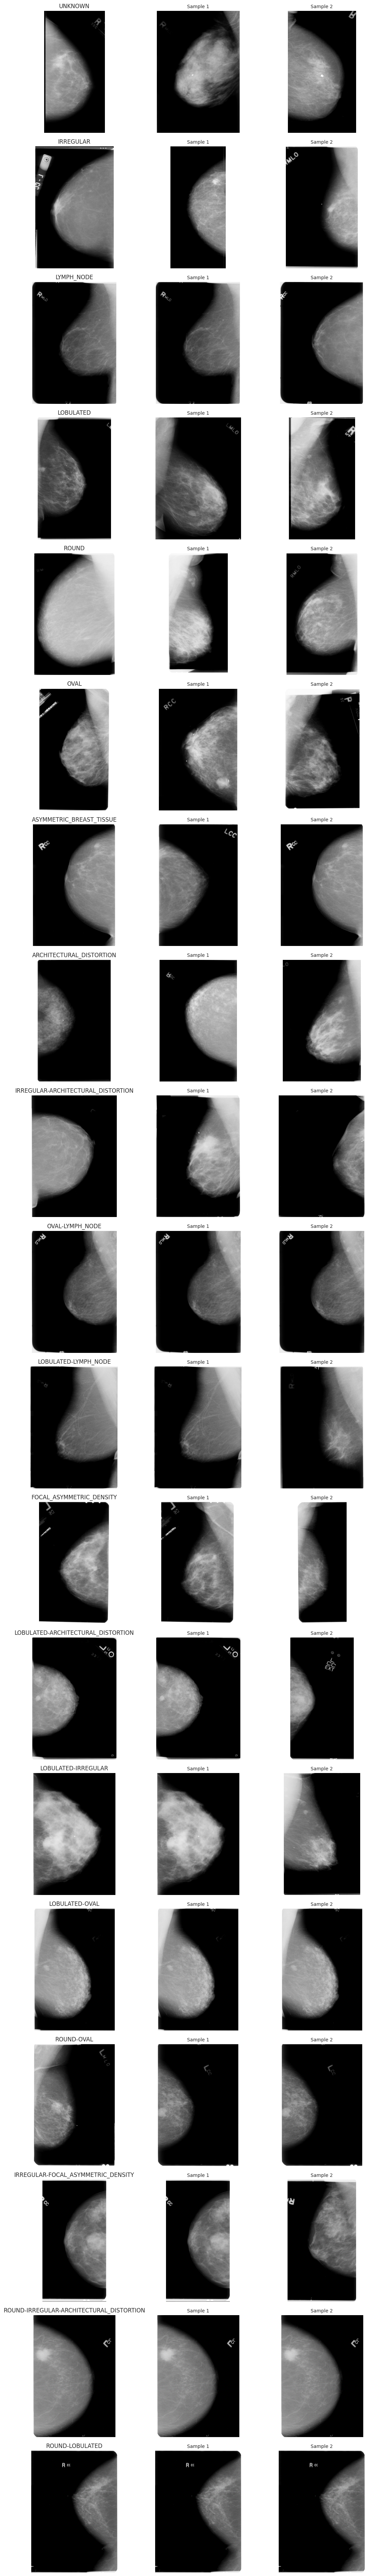

In [ ]:
# 1. Verify and Clean 'mass_shape' Column
if 'mass_shape' not in final_df.columns:
    print("Error: 'mass_shape' column not found in the DataFrame.")
else:
    # Display unique mass shapes
    print("Unique mass shapes in the dataset:")
    print(final_df['mass_shape'].unique())

    # Handle missing values
    final_df['mass_shape'] = final_df['mass_shape'].fillna('UNKNOWN')

    # Standardize labels (e.g., uppercase)
    final_df['mass_shape'] = final_df['mass_shape'].str.upper()

    # Re-define mass_shape_categories after cleaning
    mass_shape_categories = final_df['mass_shape'].unique()
    print("\nMass Shape Categories to Visualize:")
    print(mass_shape_categories)

    # 2. Sample Images
    def sample_images_by_mass_shape(df, mass_shape, n=3):
        subset = df[df['mass_shape'] == mass_shape]
        if len(subset) < n:
            print(f"Warning: Only {len(subset)} images found for mass shape '{mass_shape}'.")
            return subset
        return subset.sample(n, random_state=42)

    samples_per_shape = 3
    sampled_images = {}

    for shape in mass_shape_categories:
        sampled = sample_images_by_mass_shape(final_df, shape, n=samples_per_shape)
        sampled_images[shape] = sampled

    # 3. Define Plotting Function
    def plot_mass_shape_images(sampled_images, samples_per_shape=3):
        import math

        num_shapes = len(sampled_images)
        plt.figure(figsize=(samples_per_shape * 4, num_shapes * 4))

        for idx, (shape, df_samples) in enumerate(sampled_images.items()):
            for i in range(samples_per_shape):
                ax = plt.subplot(num_shapes, samples_per_shape, idx * samples_per_shape + i + 1)
                try:
                    img_path = df_samples.iloc[i]['corrected_image_path']
                    img = Image.open(img_path)
                    plt.imshow(img, cmap='gray')
                    plt.axis('off')

                    if i == 0:
                        ax.set_title(f"{shape}", fontsize=12)
                    else:
                        ax.set_title(f"Sample {i}", fontsize=10)
                except IndexError:
                    plt.text(0.5, 0.5, 'No Image', horizontalalignment='center', verticalalignment='center')
                    plt.axis('off')
                except FileNotFoundError:
                    plt.text(0.5, 0.5, 'Image Not Found', horizontalalignment='center', verticalalignment='center')
                    plt.axis('off')

        plt.tight_layout()
        plt.show()

    # 4. Plot the Images
    plot_mass_shape_images(sampled_images, samples_per_shape=samples_per_shape)
